# Kidney study — transcript conflict analysis

Each transcript is a semi-structured interview where a participant was shown
**3 pairwise comparisons** (Patient A vs Patient B) and asked which patient
should receive a kidney transplant.

This notebook sends each transcript to Claude and asks it to identify which
of the 3 comparisons showed signs of conflict or difficulty, based purely
on speech patterns.

**Setup:** uses the API key from `../412study/.env`


In [1]:
import sys
!{sys.executable} -m pip install anthropic python-docx python-dotenv --quiet

import anthropic
import pandas as pd
import glob
import os
import docx
from pydantic import BaseModel
from typing import Optional, List
from dotenv import load_dotenv

load_dotenv('../412study/.env')
assert os.environ.get('ANTHROPIC_API_KEY'), 'ANTHROPIC_API_KEY not found — check 412study/.env'
client = anthropic.Anthropic()
print('Client ready.')



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Client ready.


In [2]:
class PairwiseDecision(BaseModel):
    comparison_num: int          # 1, 2, or 3
    choice: str                  # 'A', 'B', or 'unclear'
    conflicted: bool             # True if clear signs of difficulty on this comparison
    difficulty_score: int        # 1 (instant) to 5 (prolonged struggle)
    evidence: Optional[str]      # verbatim quote (<30 words) showing conflict, or None

class TranscriptAnalysis(BaseModel):
    decisions: List[PairwiseDecision]

print('Schema defined.')


Schema defined.


In [3]:
SYSTEM_PROMPT = """You are analyzing a verbatim transcript of a research interview about kidney
transplant allocation. During the interview, the participant was shown exactly 3 pairwise
comparisons — each presenting two patients (Patient A and Patient B) who differ on two
features — and asked which patient should receive the kidney.

Your job:
1. Find each of the 3 pairwise comparisons in order. The 1st comparison encountered = 1,
   2nd = 2, 3rd = 3.
2. For each comparison output:
   - comparison_num: 1, 2, or 3
   - choice: 'A', 'B', or 'unclear' (only 'unclear' if genuinely unresolvable)
   - conflicted: true ONLY when there is clear evidence of genuine uncertainty or
     difficulty on THAT specific comparison
   - difficulty_score: 1 (instant, no hesitation) to 5 (prolonged deliberation)
   - evidence: a verbatim quote under 30 words showing the conflict, or null

Signs of conflict/difficulty to look for:
- Explicit statements: 'this is hard', 'tough one', 'I'm torn', 'I'm not sure', 'it's close'
- Self-correction or changing their mind mid-sentence
- Extended back-and-forth before deciding
- Asking for clarification because they cannot decide
- Long hedging before stating a choice ('I think maybe', 'probably', 'I guess')
- Expressing discomfort with having to choose at all

Important: most comparisons will NOT be conflicted. Only mark conflicted=true when the
transcript shows clear evidence of genuine uncertainty on that specific comparison.
difficulty_score should reflect effort on that decision specifically."""

print('System prompt ready.')


System prompt ready.


In [4]:
def extract_docx(path: str) -> str:
    """Extract full text from a .docx file."""
    doc = docx.Document(path)
    return '\n'.join(p.text.strip() for p in doc.paragraphs if p.text.strip())


def analyze_transcript(person_id: str, text: str) -> TranscriptAnalysis:
    """Send transcript to Claude and get structured conflict analysis."""
    response = client.messages.parse(
        model='claude-opus-4-6',
        max_tokens=2000,
        system=[
            {
                'type': 'text',
                'text': SYSTEM_PROMPT,
                'cache_control': {'type': 'ephemeral'},
            }
        ],
        messages=[
            {
                'role': 'user',
                'content': f'Participant ID: {person_id}\n\n{text}'
            }
        ],
        output_format=TranscriptAnalysis,
    )
    return response.parsed_output


print('Functions defined.')


Functions defined.


In [5]:
TRANSCRIPT_CSV = 'kidney_transcript_difficulty.csv'

docx_files = sorted(glob.glob('cleantranscripts/*_clean.docx'))
print(f'Found {len(docx_files)} transcripts.')

if os.path.exists(TRANSCRIPT_CSV):
    print(f'Found {TRANSCRIPT_CSV} — skipping transcript analysis API calls.')
    all_results = None   # sentinel: downstream cells will load from CSV
else:
    all_results = {}
    failed = []

    for path in docx_files:
        person_id = os.path.basename(path).replace('_clean.docx', '')
        print(f'Analyzing {person_id}...', end=' ', flush=True)
        try:
            text     = extract_docx(path)
            analysis = analyze_transcript(person_id, text)
            all_results[person_id] = analysis
            n_conf = sum(1 for d in analysis.decisions if d.conflicted)
            print(f'done. {len(analysis.decisions)} comparisons, {n_conf} conflicted.')
        except Exception as e:
            print(f'FAILED: {e}')
            failed.append(person_id)

    print(f'\nComplete. {len(all_results)} succeeded, {len(failed)} failed.')
    if failed:
        print(f'Failed: {failed}')


Found 20 transcripts.
Found kidney_transcript_difficulty.csv — skipping transcript analysis API calls.


In [6]:
if all_results is None:
    # Load from cached CSV
    df = pd.read_csv(TRANSCRIPT_CSV)
    print(f'Loaded {len(df)} rows from {TRANSCRIPT_CSV}')
else:
    # Flatten from API results
    rows = []
    for person_id, analysis in all_results.items():
        for d in analysis.decisions:
            rows.append({
                'personID':         person_id,
                'comparison':       d.comparison_num,
                'choice':           d.choice,
                'conflicted':       d.conflicted,
                'difficulty_score': d.difficulty_score,
                'evidence':         d.evidence,
            })
    df = pd.DataFrame(rows)

print(df.shape)
df


Loaded 60 rows from kidney_transcript_difficulty.csv
(60, 6)


,personID,comparison,choice,conflicted,difficulty_score,evidence
0,16234,1,B,False,1,"""That one to me is easy. I would go with patie..."
1,16234,2,B,False,2,"""I think I would get with patient B again beca..."
2,16234,3,A,False,2,"""I think I would go with Patient A again, beca..."
3,19857,1,B,True,4,"This one's a tough one, because the one that h..."
4,19857,2,A,False,2,NaN
5,19857,3,A,True,5,Gosh! This one's hard. It keeps getting harder...
6,23405,1,A,True,3,I'm doing mental combat with myself. but I fee...
7,23405,2,A,True,4,"That one's really hard, though."
8,23405,3,B,True,5,one moment I think I would lean towards A and ...
9,25171,1,A,True,4,So. Oof that's so hard when you have those two.


In [7]:
# Summary per person
summary = df.groupby('personID').agg(
    n_comparisons=('comparison', 'count'),
    n_conflicted=('conflicted', 'sum'),
    avg_difficulty=('difficulty_score', 'mean'),
    max_difficulty=('difficulty_score', 'max'),
).assign(pct_conflicted=lambda d: d['n_conflicted'] / d['n_comparisons'] * 100)
print(summary.sort_values('pct_conflicted', ascending=False).round(1).to_string())


          n_comparisons  n_conflicted  avg_difficulty  max_difficulty  pct_conflicted
personID                                                                             
23405                 3             3             4.0               5           100.0
45865                 3             3             4.0               5           100.0
66158                 3             3             3.7               4           100.0
99453                 3             2             3.3               4            66.7
80894                 3             2             3.0               4            66.7
42828                 3             2             3.7               5            66.7
68470                 3             2             3.0               4            66.7
19857                 3             2             3.7               5            66.7
62264                 3             1             3.0               5            33.3
76769                 3             1             1.7 

In [8]:
# Which comparison (1/2/3) is hardest overall?
print('Conflict rate by comparison number:')
print(df.groupby('comparison')['conflicted'].mean().round(3).to_string())
print()

# Show all conflicted decisions with evidence
conflicted = df[df['conflicted']].copy()
print(f'Total conflicted: {len(conflicted)} across {conflicted["personID"].nunique()} persons\n')
for pid in sorted(conflicted['personID'].unique()):
    p = conflicted[conflicted['personID'] == pid]
    print(f'===== {pid} =====')
    for _, row in p.iterrows():
        print(f'  Q{row["comparison"]} [diff={row["difficulty_score"]}] chose {row["choice"]}')
        if row['evidence']:
            print(f'     "{row["evidence"]}"')
    print()


Conflict rate by comparison number:
comparison
1    0.50
2    0.25
3    0.65

Total conflicted: 28 across 17 persons

===== 19857 =====
  Q1 [diff=4] chose B
     "This one's a tough one, because the one that has less years of life has been on the waiting list longer."
  Q3 [diff=5] chose A
     "Gosh! This one's hard. It keeps getting harder. Let me see."

===== 23405 =====
  Q1 [diff=3] chose A
     "I'm doing mental combat with myself. but I feel like I strongly lean towards A"
  Q2 [diff=4] chose A
     "That one's really hard, though."
  Q3 [diff=5] chose B
     "one moment I think I would lean towards A and it's because of the dependent, and that next moment I'm thinking, no, B, because 20 years."

===== 25171 =====
  Q1 [diff=4] chose A
     "So. Oof that's so hard when you have those two."

===== 28789 =====
  Q3 [diff=5] chose B
     ""That one's a lot harder." "That one's tough." "I'm not gonna lie, I guess I went with what when I was in a spot of indecisiveness""

===== 3177

In [9]:
df.to_csv('kidney_transcript_difficulty.csv', index=False)
print('Saved kidney_transcript_difficulty.csv')


Saved kidney_transcript_difficulty.csv


In [10]:
# ─── Cell 10: Feature extraction ─────────────────────────────────────────────
# kidney_features_raw.csv stores absolute A/B feature values for every comparison.
# If it already exists the API calls are skipped entirely.
# The raw CSV is what cells 11 and 14 read from when loading from cache.

from pydantic import BaseModel
from typing import List

class PatientProfile(BaseModel):
    dependents:   int   # number of dependents (e.g. 0, 1, 2, 3)
    life_years:   int   # years of life gained from transplant (e.g. 10, 20, 25)
    obesity:      int   # 0=underweight, 1=normal, 2=overweight, 3=obese, 4=morbidly obese
    work_hours:   int   # expected work hours/week post-transplant
    wait_years:   int   # years on transplant waiting list
    crime:        int   # number of past serious crimes committed (0 if none)

class ComparisonFeatures(BaseModel):
    comparison_num: int
    patient_A: PatientProfile
    patient_B: PatientProfile
    choice: str   # 'A', 'B', or 'unclear'

class TranscriptFeatures(BaseModel):
    comparisons: List[ComparisonFeatures]


EXTRACT_PROMPT = """You are extracting structured feature data from a kidney allocation interview transcript.
The participant was shown exactly 3 pairwise comparisons. The 2nd and 3rd comparisons are
IDENTICAL across every interview — use the values below verbatim for those two:

Comparison 2 (fixed):
  Patient A: dependents=2, life_years=25, obesity=1 (normal weight), work_hours=10, wait_years=5, crime=0
  Patient B: dependents=1, life_years=20, obesity=2 (overweight),    work_hours=30, wait_years=7, crime=0

Comparison 3 (fixed):
  Patient A: dependents=1, life_years=10, obesity=0 (underweight), work_hours=20, wait_years=5, crime=0
  Patient B: dependents=0, life_years=20, obesity=3 (obese),       work_hours=40, wait_years=3, crime=0

Obesity integer codes: 0=underweight, 1=normal/normal weight, 2=overweight, 3=obese, 4=morbidly obese.

For Comparison 1 (which varies per participant), read the transcript to extract the exact
feature values the interviewer describes for Patient A and Patient B.

For ALL THREE comparisons, return COMPLETE feature values for BOTH patients — do NOT leave
any field blank or null, even if two features happen to be equal between the patients.
Also return which patient the participant ultimately chose (choice: 'A' or 'B' or 'unclear').
"""

# Use an absolute path anchored to this notebook's directory so the check and
# save always resolve to the same location regardless of the kernel's CWD.
_NB_DIR = os.path.dirname(os.path.abspath('kidney_transcript_model.ipynb'))
FEATURES_RAW_CSV = os.path.join(_NB_DIR, 'kidney_features_raw.csv')
print(f'Features CSV path : {FEATURES_RAW_CSV}')
print(f'File exists       : {os.path.exists(FEATURES_RAW_CSV)}')

def extract_features(person_id: str, text: str) -> TranscriptFeatures:
    response = client.messages.parse(
        model='claude-opus-4-6',
        max_tokens=2000,
        system=[{'type': 'text', 'text': EXTRACT_PROMPT,
                 'cache_control': {'type': 'ephemeral'}}],
        messages=[{'role': 'user',
                   'content': f'Participant ID: {person_id}\n\n{text}'}],
        output_format=TranscriptFeatures,
    )
    return response.parsed_output


if os.path.exists(FEATURES_RAW_CSV):
    print(f'\nFound {FEATURES_RAW_CSV} — skipping feature extraction API calls.')
    feat_raw_df = pd.read_csv(FEATURES_RAW_CSV)
    all_features = None   # sentinel: downstream cells use feat_raw_df instead
    print(f'Loaded {len(feat_raw_df)} rows ({feat_raw_df["personID"].nunique()} persons).')
else:
    print('\nCSV not found — running feature extraction API calls...')
    all_features = {}
    for path in docx_files:
        person_id = os.path.basename(path).replace('_clean.docx', '')
        print(f'Extracting {person_id}...', end=' ', flush=True)
        try:
            text = extract_docx(path)
            feats = extract_features(person_id, text)
            all_features[person_id] = feats
            for c in feats.comparisons:
                A, B = c.patient_A, c.patient_B
                print(f'\n  Q{c.comparison_num}: '
                      f'A=({A.dependents},{A.life_years},{A.obesity},{A.work_hours},{A.wait_years},{A.crime})'
                      f' B=({B.dependents},{B.life_years},{B.obesity},{B.work_hours},{B.wait_years},{B.crime})'
                      f' →{c.choice}', end='')
            print()
        except Exception as e:
            print(f'FAILED: {e}')

    # Save raw absolute features so future runs skip the API
    raw_rows = []
    for pid, feats in all_features.items():
        for c in feats.comparisons:
            A, B = c.patient_A, c.patient_B
            raw_rows.append({
                'personID': pid, 'comparison': c.comparison_num, 'choice': c.choice,
                'A_dep': A.dependents, 'A_life': A.life_years, 'A_obesity': A.obesity,
                'A_work': A.work_hours, 'A_wait': A.wait_years, 'A_crime': A.crime,
                'B_dep': B.dependents, 'B_life': B.life_years, 'B_obesity': B.obesity,
                'B_work': B.work_hours, 'B_wait': B.wait_years, 'B_crime': B.crime,
            })
    feat_raw_df = pd.DataFrame(raw_rows)
    feat_raw_df.to_csv(FEATURES_RAW_CSV, index=False)
    print(f'\nSaved {FEATURES_RAW_CSV} ({len(feat_raw_df)} rows).')

Features CSV path : /Users/michellesi/Desktop/harvard/topmodel/kidneystudy/kidney_features_raw.csv
File exists       : True

Found /Users/michellesi/Desktop/harvard/topmodel/kidneystudy/kidney_features_raw.csv — skipping feature extraction API calls.
Loaded 60 rows (20 persons).


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize

FEATURES = ['dependents', 'life_years', 'weight_num', 'work_hours', 'wait_years', 'crime_num']

# obesity integer → "distance from normal" for BT sign correction:
#   0=underweight→-1, 1=normal→0, 2=overweight→1, 3=obese→2
def profile_to_vec(p: PatientProfile) -> np.ndarray:
    return np.array([
        float(p.dependents),
        float(p.life_years),
        float(p.obesity - 1),
        float(p.work_hours),
        float(p.wait_years),
        float(p.crime),
    ])


if all_features is None:
    # Reconstruct feat_df from the cached raw-features CSV
    rows = []
    for _, row in feat_raw_df.iterrows():
        y = 1.0 if row['choice'] == 'A' else (0.0 if row['choice'] == 'B' else np.nan)
        if not np.isnan(y):
            rows.append({
                'personID':   row['personID'],
                'comparison': row['comparison'],
                'choice':     row['choice'],
                'y':          y,
                'dx_dependents': row['A_dep']            - row['B_dep'],
                'dx_life_years': row['A_life']           - row['B_life'],
                'dx_weight_num': (row['A_obesity'] - 1)  - (row['B_obesity'] - 1),
                'dx_work_hours': row['A_work']           - row['B_work'],
                'dx_wait_years': row['A_wait']           - row['B_wait'],
                'dx_crime_num':  row['A_crime']          - row['B_crime'],
            })
    feat_df = pd.DataFrame(rows)
    print(f'Reconstructed feat_df from CSV: {len(feat_df)} rows')
else:
    # Build pooled comparison matrix from API results
    rows = []
    for person_id, feats in all_features.items():
        for comp in feats.comparisons:
            vA = profile_to_vec(comp.patient_A)
            vB = profile_to_vec(comp.patient_B)
            dx = vA - vB
            y  = 1.0 if comp.choice == 'A' else (0.0 if comp.choice == 'B' else np.nan)
            if not np.isnan(y):
                rows.append({'personID': person_id,
                             'comparison': comp.comparison_num,
                             'choice': comp.choice, 'y': y,
                             **{f'dx_{f}': dx[i] for i, f in enumerate(FEATURES)}})
    feat_df = pd.DataFrame(rows)

print(f'Pooled comparisons: {len(feat_df)} rows, {feat_df["personID"].nunique()} persons')
print(feat_df[['personID','comparison','choice'] + [f'dx_{f}' for f in FEATURES]].to_string())


Reconstructed feat_df from CSV: 60 rows
Pooled comparisons: 60 rows, 20 persons
    personID  comparison choice  dx_dependents  dx_life_years  dx_weight_num  dx_work_hours  dx_wait_years  dx_crime_num
0      16234           1      B              0             15              0              0             -6             0
1      16234           2      B              1              5             -1            -20             -2             0
2      16234           3      A              1            -10             -3            -20              2             0
3      19857           1      B              0             15              0              0             -6             0
4      19857           2      A              1              5             -1            -20             -2             0
5      19857           3      A              1            -10             -3            -20              2             0
6      23405           1      A             -3              0            

In [12]:
# Sign corrections: higher processed value = higher donation/allocation priority
#   dependents: KEEP  (+1) — more dependents = more people rely on this person
#   life_years: KEEP  (+1) — more years gained = better outcome
#   weight_num: FLIP  (-1) — further from normal = worse health = more urgent
#   work_hours: ambiguous — skip (set SIGN=0 to exclude)
#   wait_years: KEEP  (+1) — longer wait = higher priority
#   crime_num:  FLIP  (-1) — criminal history = lower priority
SIGN = np.array([1., 1., -1., 0., 1., -1.])
active = SIGN != 0
FEAT_ACTIVE = [f for f, a in zip(FEATURES, active) if a]
SIGN_ACTIVE  = SIGN[active]
print(f'Active features ({len(FEAT_ACTIVE)}): {FEAT_ACTIVE}')
print(f'Signs: {dict(zip(FEAT_ACTIVE, SIGN_ACTIVE.astype(int)))}')


def simplex_project(w):
    w_pos = np.clip(w, 0, None)
    total = w_pos.sum()
    return w_pos / total if total > 0 else np.ones(len(w)) / len(w)


def fit_bt(dx, y, reg=1e-2):
    """Fit BT with small L2 regularisation (needed for small N).
    Returns raw weights."""
    K = dx.shape[1]
    def nll(w):
        eta = dx @ w
        loss = float(np.sum(np.logaddexp(0., eta) - y * eta)) + reg * float(np.dot(w, w))
        grad = dx.T @ (expit(eta) - y) + 2 * reg * w
        return loss, grad
    res = minimize(nll, np.zeros(K), jac=True, method='L-BFGS-B',
                   options={'maxiter': 2000, 'ftol': 1e-15, 'gtol': 1e-9})
    return res.x


# Build sign-corrected, normalised dx matrix
dx_cols = [f'dx_{f}' for f in FEATURES]
dx_all  = feat_df[dx_cols].values * SIGN          # shape (N, 6), sign-corrected
dx_act  = dx_all[:, active]                        # drop work_hours
y_all   = feat_df['y'].values

# Normalise by max absolute value per feature (use non-nan)
col_max = np.nanmax(np.abs(dx_act), axis=0)
col_max = np.where(col_max > 0, col_max, 1.0)
dx_norm = np.where(np.isnan(dx_act), 0., dx_act / col_max)  # fill nan→0 (feature not varied)

# ── Pooled BT ─────────────────────────────────────────────────────────────────
w_pooled    = fit_bt(dx_norm, y_all)
omega_pooled = simplex_project(w_pooled)
acc_pooled  = ((dx_norm @ w_pooled >= 0) == y_all.astype(bool)).mean()

print('Pooled BT (all persons × all comparisons)')
print(f'  N = {len(y_all)}  acc = {acc_pooled:.1%}')
print(f'  raw w:  {dict(zip(FEAT_ACTIVE, np.round(w_pooled, 3)))}')
print(f'  omega:  {dict(zip(FEAT_ACTIVE, np.round(omega_pooled, 3)))}')

# ── Per-person BT ─────────────────────────────────────────────────────────────
print('\nPer-person BT (3 comparisons each, regularised):')
person_weights = []
header = '  '.join(f'{f[:8]:>9s}' for f in FEAT_ACTIVE)
print(f'{"person":>8}  {"N":>3}  {"acc":>5}  {header}')

for pid in sorted(feat_df['personID'].unique()):
    sub   = feat_df[feat_df['personID'] == pid]
    dx_p  = np.where(np.isnan(dx_act[sub.index]), 0.,
                     dx_act[sub.index] / col_max)
    y_p   = sub['y'].values
    w_p   = fit_bt(dx_p, y_p)
    om_p  = simplex_project(w_p)
    acc_p = ((dx_p @ w_p >= 0) == y_p.astype(bool)).mean()
    om_str = '  '.join(f'{v:9.3f}' for v in om_p)
    print(f'{pid:>8}  {len(y_p):>3}  {acc_p:>5.0%}  {om_str}')
    person_weights.append({'personID': pid, 'acc': acc_p,
                           **{f: om_p[i] for i, f in enumerate(FEAT_ACTIVE)}})

pw_df = pd.DataFrame(person_weights).set_index('personID')


Active features (5): ['dependents', 'life_years', 'weight_num', 'wait_years', 'crime_num']
Signs: {'dependents': 1, 'life_years': 1, 'weight_num': -1, 'wait_years': 1, 'crime_num': -1}
Pooled BT (all persons × all comparisons)
  N = 60  acc = 70.0%
  raw w:  {'dependents': 4.031, 'life_years': 3.095, 'weight_num': -0.475, 'wait_years': 4.574, 'crime_num': 0.0}
  omega:  {'dependents': 0.345, 'life_years': 0.265, 'weight_num': 0.0, 'wait_years': 0.391, 'crime_num': 0.0}

Per-person BT (3 comparisons each, regularised):
  person    N    acc   dependen   life_yea   weight_n   wait_yea   crime_nu
   16234    3   100%      0.000      0.000      0.136      0.864      0.000
   19857    3   100%      0.479      0.000      0.386      0.135      0.000
   23405    3   100%      0.000      0.773      0.169      0.058      0.000
   25171    3   100%      0.389      0.611      0.000      0.000      0.000
   28789    3   100%      0.490      0.192      0.000      0.317      0.000
   31772    3   100%

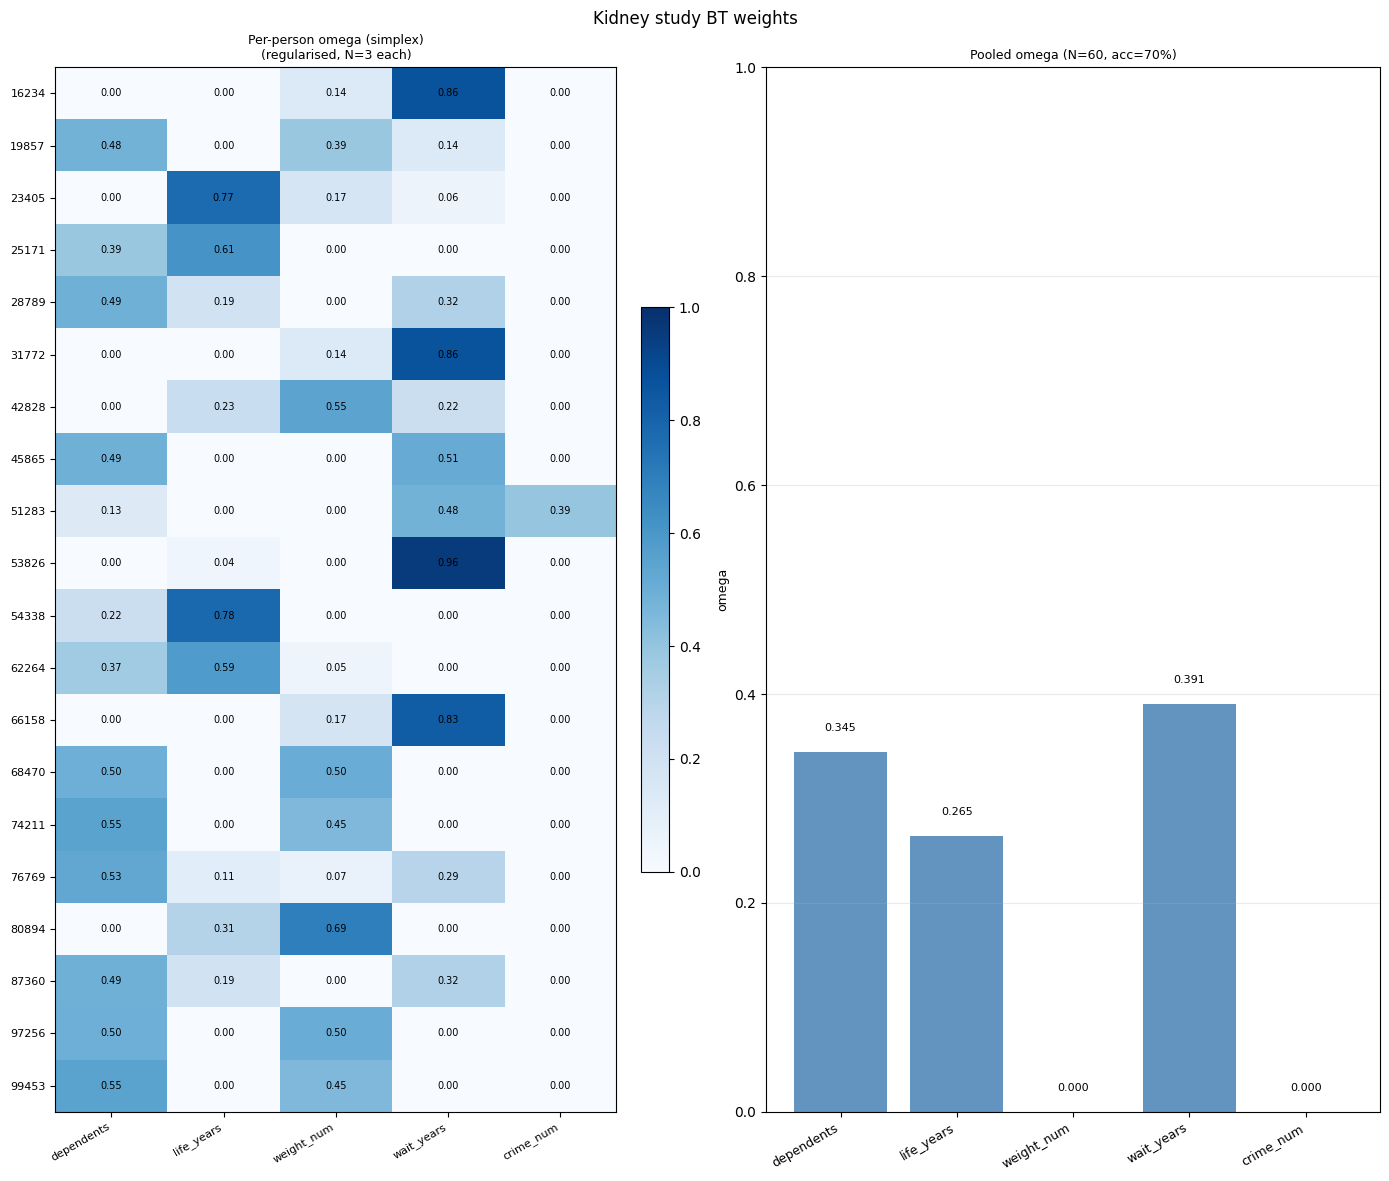

Saved kidney_bt_omega.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 0.45 * len(pw_df) + 3))

# Left: per-person omega heatmap
omega_mat = pw_df[FEAT_ACTIVE].values
ax = axes[0]
im = ax.imshow(omega_mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(FEAT_ACTIVE)))
ax.set_xticklabels(FEAT_ACTIVE, fontsize=8, rotation=30, ha='right')
ax.set_yticks(range(len(pw_df)))
ax.set_yticklabels(pw_df.index, fontsize=8)
ax.set_title('Per-person omega (simplex)\n(regularised, N=3 each)', fontsize=9)
for i in range(omega_mat.shape[0]):
    for j in range(omega_mat.shape[1]):
        ax.text(j, i, f'{omega_mat[i,j]:.2f}', ha='center', va='center', fontsize=7)

# Right: pooled omega bar chart
ax2 = axes[1]
colors = ['tomato' if w < 0 else 'steelblue' for w in w_pooled]
ax2.bar(range(len(FEAT_ACTIVE)), omega_pooled, color='steelblue', alpha=0.85)
ax2.set_xticks(range(len(FEAT_ACTIVE)))
ax2.set_xticklabels(FEAT_ACTIVE, fontsize=9, rotation=30, ha='right')
ax2.set_ylim(0, 1)
ax2.set_ylabel('omega', fontsize=9)
ax2.set_title(f'Pooled omega (N={len(y_all)}, acc={acc_pooled:.0%})', fontsize=9)
for i, v in enumerate(omega_pooled):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8)
ax2.grid(True, alpha=0.25, axis='y')

plt.suptitle('Kidney study BT weights', fontsize=12)
plt.tight_layout()
plt.savefig('kidney_bt_omega.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved kidney_bt_omega.png')


In [14]:
# ─── Cell 14: Polytope reduction setup ───────────────────────────────────────
# Sign convention (must match BT's SIGN array in cell 12):
#   dependents:   +1  (more dependents = higher priority)
#   life_years:   +1  (more years gained = higher priority)
#   obesity:      -1  → flip in Patient: Patient.obesity = OBESITY_FLIP - raw_obesity
#                      so lower raw obesity → higher Patient value → positive gap when A is less obese ✓
#   work_hours:   0 in BT (excluded); kept in polytope with implicit +1
#   wait_years:   +1  (longer wait = higher priority)
#   crime: excluded from Patient (not in core.py's 5-feature set)
#
# BT applies SIGN in cell 12. Polytope needs the flip baked into Patient objects.

import sys
sys.path.insert(0, '../learning-algo')
from core import (Patient, PairwiseQuery, filter_samples_by_response,
                  sample_from_simplex, resample_from_feasible_set,
                  compute_diameter, FEATURE_NAMES, TAU, TAU_PRIME)
from core import compute_frame_gaps

OBESITY_FLIP  = 5   # Patient.obesity = OBESITY_FLIP - raw_obesity (keeps values in 0-5 range)
LAMBDA_X_STUDY = 2.0  # a 1-unit raw feature diff → gap=2 > tau=1, so every differing dim is active

def raw_to_patient(dep, life, obesity_raw, work, wait) -> Patient:
    """Build a Patient with sign-corrected obesity (lower raw obesity → higher Patient value)."""
    return Patient(
        elderlyDep      = dep,
        lifeYearsGained = life,
        obesity         = OBESITY_FLIP - obesity_raw,   # sign flip
        weeklyWorkhours = work,
        yearsWaiting    = wait,
    )

def profile_to_patient(p: PatientProfile) -> Patient:
    return raw_to_patient(p.dependents, p.life_years, p.obesity, p.work_hours, p.wait_years)

# ── Hardcoded Q2 and Q3 with sign-corrected obesity ───────────────────────────
# Raw Q2: A=(dep=2,life=25,obes=1,work=10,wait=5), B=(dep=1,life=20,obes=2,work=30,wait=7)
# Raw Q3: A=(dep=1,life=10,obes=0,work=20,wait=5), B=(dep=0,life=20,obes=3,work=40,wait=3)
Q2 = PairwiseQuery(
    patient_left  = raw_to_patient(2, 25, 1, 10, 5),   # A
    patient_right = raw_to_patient(1, 20, 2, 30, 7),   # B
)
Q3 = PairwiseQuery(
    patient_left  = raw_to_patient(1, 10, 0, 20, 5),   # A
    patient_right = raw_to_patient(0, 20, 3, 40, 3),   # B
)

def build_q1(pid) -> PairwiseQuery:
    """Build Q1 PairwiseQuery with sign-corrected obesity — from API results or cached CSV.
    Accepts pid as int or str (normalises internally)."""
    pid_str = str(pid)
    if all_features is not None:
        comp = next(c for c in all_features[pid_str].comparisons if c.comparison_num == 1)
        return PairwiseQuery(
            patient_left  = profile_to_patient(comp.patient_A),
            patient_right = profile_to_patient(comp.patient_B),
        )
    else:
        row = feat_raw_df[(feat_raw_df['personID'].astype(str) == pid_str) &
                          (feat_raw_df['comparison'] == 1)].iloc[0]
        return PairwiseQuery(
            patient_left  = raw_to_patient(int(row['A_dep']), int(row['A_life']),
                                           int(row['A_obesity']), int(row['A_work']), int(row['A_wait'])),
            patient_right = raw_to_patient(int(row['B_dep']), int(row['B_life']),
                                           int(row['B_obesity']), int(row['B_work']), int(row['B_wait'])),
        )

def map_response(row) -> str:
    if row['conflicted']:
        return 'incomparable'
    return 'left' if row['choice'] == 'A' else 'right'

# Verify active frames and sign-corrected gaps for Q2 and Q3
print(f'Q2 sign-corrected Patient values:')
print(f'  A={Q2.patient_left}')
print(f'  B={Q2.patient_right}')
g2, af2 = compute_frame_gaps(Q2, lambda_x=LAMBDA_X_STUDY)
print(f'  gaps={dict(zip(FEATURE_NAMES, g2.round(1)))}  active={[FEATURE_NAMES[i] for i in sorted(af2)]}')

print(f'\nQ3 sign-corrected Patient values:')
print(f'  A={Q3.patient_left}')
print(f'  B={Q3.patient_right}')
g3, af3 = compute_frame_gaps(Q3, lambda_x=LAMBDA_X_STUDY)
print(f'  gaps={dict(zip(FEATURE_NAMES, g3.round(1)))}  active={[FEATURE_NAMES[i] for i in sorted(af3)]}')

print(f'\nQ1 per person (sign-corrected):')
for pid in sorted(df['personID'].unique()):
    try:
        q1 = build_q1(pid)
        g1, af1 = compute_frame_gaps(q1, lambda_x=LAMBDA_X_STUDY)
        pA, pB = q1.patient_left, q1.patient_right
        print(f'  {pid}  A=({pA.elderlyDep},{pA.lifeYearsGained},{pA.obesity},{pA.weeklyWorkhours},{pA.yearsWaiting})'
              f'  B=({pB.elderlyDep},{pB.lifeYearsGained},{pB.obesity},{pB.weeklyWorkhours},{pB.yearsWaiting})'
              f'  active={[FEATURE_NAMES[i] for i in sorted(af1)]}')
    except Exception as e:
        print(f'  {pid}: ERROR {e}')

Q2 sign-corrected Patient values:
  A=Patient(elder=2, life=25, obesity=4, work=10, wait=5)
  B=Patient(elder=1, life=20, obesity=3, work=30, wait=7)
  gaps={'elderlyDep': 2.0, 'lifeYearsGained': 10.0, 'obesity': 2.0, 'weeklyWorkhours': -40.0, 'yearsWaiting': -4.0}  active=['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']

Q3 sign-corrected Patient values:
  A=Patient(elder=1, life=10, obesity=5, work=20, wait=5)
  B=Patient(elder=0, life=20, obesity=2, work=40, wait=3)
  gaps={'elderlyDep': 2.0, 'lifeYearsGained': -20.0, 'obesity': 6.0, 'weeklyWorkhours': -40.0, 'yearsWaiting': 4.0}  active=['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']

Q1 per person (sign-corrected):
  16234  A=(0,25,4,20,1)  B=(0,10,4,20,7)  active=['lifeYearsGained', 'yearsWaiting']
  19857  A=(0,25,4,20,1)  B=(0,10,4,20,7)  active=['lifeYearsGained', 'yearsWaiting']
  23405  A=(0,15,4,20,7)  B=(3,15,4,20,1)  active=['elderlyDep', 'yearsWaiting']
  251

## Algorithms

We evaluate three methods for inferring a participant's priority weight vector $\omega \in \Delta^K$ from their responses to $N$ pairwise queries. All three use hit-and-run Markov chain Monte Carlo (MCMC) on the simplex to draw posterior samples of $\omega$; they differ in which responses they use and how the response likelihood is defined. Posterior uncertainty is summarized as the total posterior variance $\sum_k \mathrm{Var}[\omega_k]$, i.e., the trace of the sample covariance.

**Multi-Frame Polytope (MFP).** Our proposed method uses all $N$ responses, including those elicited from conflicted queries. For a given query with normalized feature difference $\phi$ and participant weight $\omega$, the model defines four response outcomes — *left*, *right*, *indifferent*, and *incomparable* — governed by two thresholds $\tau$ and $\tau'$ applied to the overall decisiveness $r = \|\phi\|_\omega$ and the signed utility gap $\delta = \phi^\top \omega$. Response probabilities are estimated via Monte Carlo integration over logistic decision noise. Conflicted responses are assigned the *incomparable* label, contributing positively to the likelihood when the query falls near the model's indecision boundary.

**Bradley-Terry MCMC (BT).** A standard Bradley-Terry baseline that uses only decisive responses; conflicted responses are discarded. The likelihood is the standard logistic model $P(\text{left} \mid \phi, \omega) = \sigma(\phi^\top \omega)$, computed exactly. Because conflicted responses are dropped rather than modeled, participants with many conflicts contribute less data and tend to yield higher posterior variance.

**Rao-Kupper MCMC (RK).** An extension of Bradley-Terry that introduces an explicit tie threshold $\theta \in (0, \Theta_{\max})$. Conflicted responses are treated as *incomparable* with probability $\sigma(\delta + \theta) - \sigma(\delta - \theta)$, allowing them to inform inference without requiring the full multi-frame likelihood. The MCMC jointly updates $\omega$ via hit-and-run and $\theta$ via a Gaussian random walk; posterior variance is reported over $\omega$ only.


In [15]:
# ─── Cell 20: BALD-notebook algorithms (no active learning) ──────────────────
# Posterior inference over omega ∈ Δ5 (the 5-simplex).
#
#   Pipeline 1 — Multi-Frame Polytope (this work, "Utilize-Indecision")
#     Data:     all responses, including "incomparable" for conflicted queries
#     Model:    4-tier decision rule with τ=0, τ'=0.25, logistic noise (closed form)
#     Prior:    implicit uniform on simplex
#     Proposal: hit-and-run MCMC
#
#   Pipeline 2 — Standard Bradley-Terry
#     Data:     decisive responses only (drop conflict)  OR
#               all responses with the participant's A/B choice (force decision)
#     Model:    logistic regression P(left) = σ(φᵀω)
#     Prior:    implicit uniform on simplex (NO L2 regularisation)
#     Proposal: same hit-and-run MCMC
#
#   Pipeline RK — Rao-Kupper (θ ≥ 1)
#     Data:     all responses; conflicted → tie
#     Model:    P(left)  = 1 / (1 + θ·e^{-Δ})
#               P(right) = 1 / (1 + θ·e^{ Δ})
#               P(tie)   = (θ²-1) / [(1 + θ·e^{-Δ})(1 + θ·e^{ Δ})]
#     Reduces to BT when θ=1 (P(tie)=0). Does NOT preserve Luce except at θ=1.
#
#   Pipeline DV — Davidson (ν ≥ 0)
#     Data:     all responses; conflicted → tie
#     Model:    P(left)  = e^{ Δ/2} / Z
#               P(right) = e^{-Δ/2} / Z
#               P(tie)   = ν      / Z      with Z = e^{Δ/2} + e^{-Δ/2} + ν
#     Reduces to BT when ν=0. Preserves the Luce odds ratio P(left)/P(right) = e^Δ.
#
# Features are normalised to [0,1] so noise scale and thresholds are commensurable.

from scipy.special import expit as _sigmoid

_NDIM      = len(FEATURE_NAMES)   # 5
_TAU       = 0
_TAU_PRIME = 0.25
_LAMBDA_X  = 1.0

# Rao-Kupper (θ ≥ 1)
_RK_THETA_MAX  = 10.0
_RK_THETA_STEP = 0.30
_RK_THETA_INIT = 1.50

# Davidson (ν ≥ 0)
_DV_NU_MAX  = 10.0
_DV_NU_STEP = 0.30
_DV_NU_INIT = 0.50

# ── Feature normalisation ────────────────────────────────────────────────────────
_all = {f: [] for f in FEATURE_NAMES}
for _, row in feat_raw_df.iterrows():
    for pfx in ["A", "B"]:
        _all["elderlyDep"].append(int(row[f"{pfx}_dep"]))
        _all["lifeYearsGained"].append(int(row[f"{pfx}_life"]))
        _all["obesity"].append(OBESITY_FLIP - int(row[f"{pfx}_obesity"]))
        _all["weeklyWorkhours"].append(int(row[f"{pfx}_work"]))
        _all["yearsWaiting"].append(int(row[f"{pfx}_wait"]))

_FEAT_LO = {f: min(v) for f, v in _all.items()}
_FEAT_HI = {f: max(v) for f, v in _all.items()}

print("Feature ranges (sign-corrected):")
for f in FEATURE_NAMES:
    print(f"  {f}: [{_FEAT_LO[f]}, {_FEAT_HI[f]}]")

def _norm(val, lo, hi):
    return (val - lo) / (hi - lo) if hi > lo else 0.5

def _norm_patient(p):
    return Patient(
        elderlyDep      = _norm(p.elderlyDep,      _FEAT_LO["elderlyDep"],      _FEAT_HI["elderlyDep"]),
        lifeYearsGained = _norm(p.lifeYearsGained, _FEAT_LO["lifeYearsGained"], _FEAT_HI["lifeYearsGained"]),
        obesity         = _norm(p.obesity,         _FEAT_LO["obesity"],         _FEAT_HI["obesity"]),
        weeklyWorkhours = _norm(p.weeklyWorkhours, _FEAT_LO["weeklyWorkhours"], _FEAT_HI["weeklyWorkhours"]),
        yearsWaiting    = _norm(p.yearsWaiting,    _FEAT_LO["yearsWaiting"],    _FEAT_HI["yearsWaiting"]),
    )

def _norm_query(q):
    return PairwiseQuery(
        patient_left  = _norm_patient(q.patient_left),
        patient_right = _norm_patient(q.patient_right),
    )

# ── Hit-and-run proposal on the simplex (shared by all pipelines) ────────────
def _hit_run_step(x, rng):
    dim = len(x)
    d = rng.standard_normal(dim); d -= d.mean()
    n = np.linalg.norm(d)
    if n < 1e-12: return x.copy()
    d /= n
    t_lo, t_hi = -np.inf, np.inf
    for j in range(dim):
        if   d[j] >  1e-12: t_lo = max(t_lo, -x[j]/d[j])
        elif d[j] < -1e-12: t_hi = min(t_hi, -x[j]/d[j])
    if t_lo >= t_hi - 1e-12: return x.copy()
    nx = x + rng.uniform(t_lo, t_hi) * d
    nx = np.maximum(nx, 0.); nx /= nx.sum()
    return nx

# ── Multi-frame likelihood helpers (Pipeline 1) — CLOSED FORM ─────────────────
def _frame_gaps_bald(q, lx=_LAMBDA_X):
    diff = q.patient_left.to_array() - q.patient_right.to_array()
    gaps = lx * diff
    active = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active

def _response_probs_mc(q, w, n_mc=100, rng=None):
    """Closed-form P(resp|q,w) under logistic decision noise; returns [left,right,indiff,incomp]."""
    gaps, active = _frame_gaps_bald(q)
    delta = float(np.dot(gaps, w))
    r     = float(sum(w[j] * abs(gaps[j]) for j in active))
    if r < _TAU:
        return np.array([0.0, 0.0, 1.0, 0.0])
    th = _TAU_PRIME * r
    p_left  = float(_sigmoid(delta - th))
    p_right = float(_sigmoid(-(delta + th)))
    p_inc   = max(0.0, 1.0 - p_left - p_right)
    return np.array([p_left, p_right, 0.0, p_inc])

def _transcript_ll(transcript, w, n_mc=50, rng=None):
    """Total log-likelihood under closed-form multi-frame model. n_mc/rng unused."""
    idx = {"left": 0, "right": 1, "indifferent": 2, "incomparable": 3}
    ll = 0.0
    for q, resp in transcript:
        probs = _response_probs_mc(q, w)
        ll += np.log(max(probs[idx[resp]], 1e-10))
    return ll

# ── Pipeline 1: Multi-Frame Polytope MCMC ──────────────────────────────────────
def sample_bayes_polytope_posterior(transcript, n_samples=500, burn_in=500,
                                    n_mc=50, rng=None):
    """Hit-and-run MH on simplex with multi-frame closed-form likelihood. Uniform prior."""
    if rng is None: rng = np.random.default_rng()
    w  = np.ones(_NDIM) / _NDIM
    ll = _transcript_ll(transcript, w)
    samples, n_acc = [], 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        llp = _transcript_ll(transcript, wp)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc += 1
        if step >= burn_in: samples.append(w.copy())
    return np.array(samples), n_acc / max(1, n_samples)

# ── Pipeline 2: Bradley-Terry MCMC (uniform prior, no L2) ─────────────────────
def sample_bt_mcmc(phis, ys, n_samples=500, burn_in=500, rng=None):
    """Hit-and-run MH on simplex with BT logistic log-likelihood. Uniform prior (no L2)."""
    if rng is None: rng = np.random.default_rng()
    if len(phis) == 0:
        return rng.dirichlet(np.ones(_NDIM), size=n_samples), 1.0

    def log_likelihood(w):
        lg  = phis @ w
        lp  = np.where(lg>=0, -np.log1p(np.exp(-lg)),   lg - np.log1p(np.exp(lg)))
        lnp = np.where(lg>=0, -lg - np.log1p(np.exp(-lg)), -np.log1p(np.exp(lg)))
        return float(np.sum(ys*lp + (1-ys)*lnp))

    w  = np.ones(_NDIM) / _NDIM
    lp = log_likelihood(w)
    samples, n_acc = [], 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        lpp = log_likelihood(wp)
        if np.log(max(rng.random(), 1e-15)) < lpp - lp:
            w, lp = wp, lpp
            if step >= burn_in: n_acc += 1
        if step >= burn_in: samples.append(w.copy())
    return np.array(samples), n_acc / max(1, n_samples)


# ── Pipeline RK: Rao-Kupper (θ ≥ 1) ──────────────────────────────────────────
# π_i/π_j = exp(Δ), θ ≥ 1.
#   P(left)  = 1 / (1 + θ·e^{-Δ})
#   P(right) = 1 / (1 + θ·e^{ Δ})
#   P(tie)   = (θ²-1) / [(1 + θ·e^{-Δ})(1 + θ·e^{ Δ})]
# Reduces to BT when θ=1 (P(tie)=0). Block-Gibbs MH on (ω, θ): hit-and-run on
# simplex for ω, reflected Gaussian RW above θ=1 for θ.
def _rk_log_probs(delta, theta):
    log_theta    = np.log(theta)
    log_term_pos = np.logaddexp(0.0, log_theta + delta)   # log(1 + θ·e^{Δ})
    log_term_neg = np.logaddexp(0.0, log_theta - delta)   # log(1 + θ·e^{-Δ})
    log_p_left   = -log_term_neg
    log_p_right  = -log_term_pos
    if theta > 1.0:
        log_p_tie = np.log(theta - 1.0) + np.log(theta + 1.0) - log_term_neg - log_term_pos
    else:
        log_p_tie = -np.inf
    return log_p_left, log_p_right, log_p_tie

def _rk_log_likelihood(phis, responses, w, theta):
    ll = 0.0
    for phi, resp in zip(phis, responses):
        delta = float(np.dot(phi, w))
        lpl, lpr, lpt = _rk_log_probs(delta, theta)
        if   resp == 'left':         ll += lpl
        elif resp == 'right':        ll += lpr
        elif resp == 'incomparable': ll += lpt if not np.isinf(lpt) else -1e10
    return ll

def sample_rk_mcmc(phis, responses, n_samples=500, burn_in=500,
                   theta_step=_RK_THETA_STEP, rng=None,
                   theta_init=_RK_THETA_INIT, theta_max=_RK_THETA_MAX):
    """Block-Gibbs MH on (ω, θ) for Rao-Kupper. Returns (samples, acc_w, acc_θ).
    Last column of samples is θ."""
    if rng is None: rng = np.random.default_rng()
    w     = np.ones(_NDIM) / _NDIM
    theta = float(theta_init)
    ll    = _rk_log_likelihood(phis, responses, w, theta)
    samples, n_acc_w, n_acc_th = [], 0, 0
    for step in range(burn_in + n_samples):
        # ω update
        wp  = _hit_run_step(w, rng)
        llp = _rk_log_likelihood(phis, responses, wp, theta)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc_w += 1
        # θ update — reflect at θ=1 (symmetric proposal)
        x = theta + rng.normal(0, theta_step)
        theta_p = (2.0 - x) if x < 1.0 else x
        if theta_p <= theta_max:
            llp = _rk_log_likelihood(phis, responses, w, theta_p)
            if np.log(max(rng.random(), 1e-15)) < llp - ll:
                theta, ll = theta_p, llp
                if step >= burn_in: n_acc_th += 1
        if step >= burn_in:
            samples.append(np.append(w.copy(), theta))
    return np.array(samples), n_acc_w / max(1, n_samples), n_acc_th / max(1, n_samples)


# ── Pipeline DV: Davidson (ν ≥ 0) ────────────────────────────────────────────
# π_i/π_j = exp(Δ), ν ≥ 0.
#   P(left)  = e^{ Δ/2} / Z
#   P(right) = e^{-Δ/2} / Z
#   P(tie)   = ν / Z       Z = e^{Δ/2} + e^{-Δ/2} + ν   (= 2 cosh(Δ/2) + ν)
# Reduces to BT when ν=0. Preserves the Luce odds-ratio: P(left)/P(right) = e^Δ.
def _davidson_log_probs(delta, nu):
    half = 0.5 * delta
    if nu > 0:
        log_nu = np.log(nu)
        log_z  = np.logaddexp(np.logaddexp(half, -half), log_nu)
        log_p_tie = log_nu - log_z
    else:
        log_z  = np.logaddexp(half, -half)
        log_p_tie = -np.inf
    log_p_left  =  half - log_z
    log_p_right = -half - log_z
    return log_p_left, log_p_right, log_p_tie

def _davidson_log_likelihood(phis, responses, w, nu):
    ll = 0.0
    for phi, resp in zip(phis, responses):
        delta = float(np.dot(phi, w))
        lpl, lpr, lpt = _davidson_log_probs(delta, nu)
        if   resp == 'left':         ll += lpl
        elif resp == 'right':        ll += lpr
        elif resp == 'incomparable': ll += lpt if not np.isinf(lpt) else -1e10
    return ll

def sample_davidson_mcmc(phis, responses, n_samples=500, burn_in=500,
                         nu_step=_DV_NU_STEP, rng=None,
                         nu_init=_DV_NU_INIT, nu_max=_DV_NU_MAX):
    """Block-Gibbs MH on (ω, ν) for Davidson tie model. Hit-and-run on simplex
    for ω, reflected Gaussian RW above ν=0 for ν. Returns (samples, acc_w, acc_ν).
    Last column of samples is ν."""
    if rng is None: rng = np.random.default_rng()
    w  = np.ones(_NDIM) / _NDIM
    nu = float(nu_init)
    ll = _davidson_log_likelihood(phis, responses, w, nu)
    samples, n_acc_w, n_acc_nu = [], 0, 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        llp = _davidson_log_likelihood(phis, responses, wp, nu)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc_w += 1
        # ν update — reflect at ν=0
        nu_p = abs(nu + rng.normal(0, nu_step))
        if nu_p <= nu_max:
            llp = _davidson_log_likelihood(phis, responses, w, nu_p)
            if np.log(max(rng.random(), 1e-15)) < llp - ll:
                nu, ll = nu_p, llp
                if step >= burn_in: n_acc_nu += 1
        if step >= burn_in:
            samples.append(np.append(w.copy(), nu))
    return np.array(samples), n_acc_w / max(1, n_samples), n_acc_nu / max(1, n_samples)


print("Algorithms ready:")
print("  Pipeline 1:  sample_bayes_polytope_posterior  (multi-frame closed-form, uniform prior)")
print("  Pipeline 2:  sample_bt_mcmc                   (BT logistic, uniform prior)")
print("  Pipeline RK: sample_rk_mcmc                   (Rao-Kupper θ≥1)")
print("  Pipeline DV: sample_davidson_mcmc             (Davidson ν≥0)")


Feature ranges (sign-corrected):
  elderlyDep: [0, 3]
  lifeYearsGained: [10, 25]
  obesity: [1, 5]
  weeklyWorkhours: [10, 40]
  yearsWaiting: [1, 7]
Algorithms ready:
  Pipeline 1:  sample_bayes_polytope_posterior  (multi-frame closed-form, uniform prior)
  Pipeline 2:  sample_bt_mcmc                   (BT logistic, uniform prior)
  Pipeline RK: sample_rk_mcmc                   (Rao-Kupper θ≥1)
  Pipeline DV: sample_davidson_mcmc             (Davidson ν≥0)


In [16]:
# ─── Cell 21: Run both algorithms per person on the 3 kidney queries ─────────
# Bayesian polytope: hit-and-run MCMC with multi-frame likelihood (all responses)
# BT MCMC:           hit-and-run MCMC with logistic likelihood (left/right only)

N_MCMC   = 500
N_BT_MC  = 500
BURN_IN  = 500

bayes_poly_results = {}
bt_bald_results    = {}

print(f"{'person':>8}  {'bp_acc':>6}  {'bt_acc':>6}  {'bp_var':>8}  {'bt_var':>8}")

for pid in sorted(df["personID"].unique()):
    pid_str = str(pid)
    if feat_raw_df["personID"].astype(str).eq(pid_str).sum() == 0:
        continue

    person_rows = df[df["personID"] == pid].sort_values("comparison")
    try:
        q1 = build_q1(pid)
    except Exception as e:
        print(f"{pid:>8}  ERROR: {e}"); continue

    query_map = {1: q1, 2: Q2, 3: Q3}
    rng = np.random.default_rng(int(pid_str[-4:]) if pid_str.isdigit() else 0)

    transcript_all = []
    phis_decisive, ys_decisive = [], []

    for _, row in person_rows.iterrows():
        comp   = int(row["comparison"])
        q_norm = _norm_query(query_map[comp])
        resp   = map_response(row)
        transcript_all.append((q_norm, resp))
        if resp in ("left", "right"):
            phis_decisive.append(q_norm.patient_left.to_array() - q_norm.patient_right.to_array())
            ys_decisive.append(1.0 if resp == "left" else 0.0)

    phis_arr = np.array(phis_decisive) if phis_decisive else np.zeros((0, _NDIM))
    ys_arr   = np.array(ys_decisive)   if ys_decisive   else np.zeros(0)

    bp_samples, bp_acc = sample_bayes_polytope_posterior(
        transcript_all, n_samples=N_MCMC, burn_in=BURN_IN, n_mc=50, rng=rng
    )
    bayes_poly_results[pid] = {
        "samples":   bp_samples,
        "mean":      bp_samples.mean(axis=0),
        "std":       bp_samples.std(axis=0),
        "total_var": bp_samples.var(axis=0).sum(),
        "acc":       bp_acc,
    }

    bt_samples, bt_acc = sample_bt_mcmc(phis_arr, ys_arr, n_samples=N_BT_MC,
                                         burn_in=BURN_IN, rng=rng)
    bt_bald_results[pid] = {
        "samples":   bt_samples,
        "mean":      bt_samples.mean(axis=0),
        "std":       bt_samples.std(axis=0),
        "total_var": bt_samples.var(axis=0).sum(),
        "acc":       bt_acc,
    }

    print(f"{pid:>8}  {bp_acc:>6.2f}  {bt_acc:>6.2f}"
          f"  {bayes_poly_results[pid]['total_var']:>8.5f}"
          f"  {bt_bald_results[pid]['total_var']:>8.5f}")

print(f"\nDone. {len(bayes_poly_results)} persons.")


  person  bp_acc  bt_acc    bp_var    bt_var
   16234    0.96    0.97   0.13130   0.12589
   19857    0.89    0.99   0.11152   0.11799
   23405    0.95    1.00   0.12557   0.13114
   25171    0.86    0.98   0.11260   0.13031
   28789    0.97    0.99   0.11317   0.12766
   31772    0.98    0.97   0.13259   0.11732
   42828    0.93    0.98   0.12239   0.13046
   45865    0.92    1.00   0.11042   0.12846
   51283    0.98    0.99   0.09578   0.12202
   53826    0.91    0.98   0.12779   0.12746
   54338    0.96    0.96   0.11463   0.13820
   62264    0.95    0.97   0.12107   0.11594
   66158    0.94    1.00   0.12408   0.13578
   68470    0.92    0.99   0.10043   0.13713
   74211    0.98    0.97   0.12591   0.11577
   76769    0.97    0.98   0.11661   0.12794
   80894    0.90    0.99   0.13878   0.15280
   87360    0.91    0.98   0.12646   0.14444
   97256    0.96    0.96   0.13989   0.10831
   99453    0.91    0.99   0.11911   0.13199

Done. 20 persons.


 tau_prime   mean_acc    mean_var   r vs BT       p
      0.05      0.946     0.11735     0.070   0.770
      0.10      0.945     0.11659     0.154   0.518
      0.15      0.945     0.11643     0.164   0.490
      0.20      0.945     0.11587     0.331   0.154
      0.25      0.944     0.11614     0.362   0.117
      0.35      0.943     0.11572     0.359   0.120
      0.50      0.942     0.11420     0.253   0.281


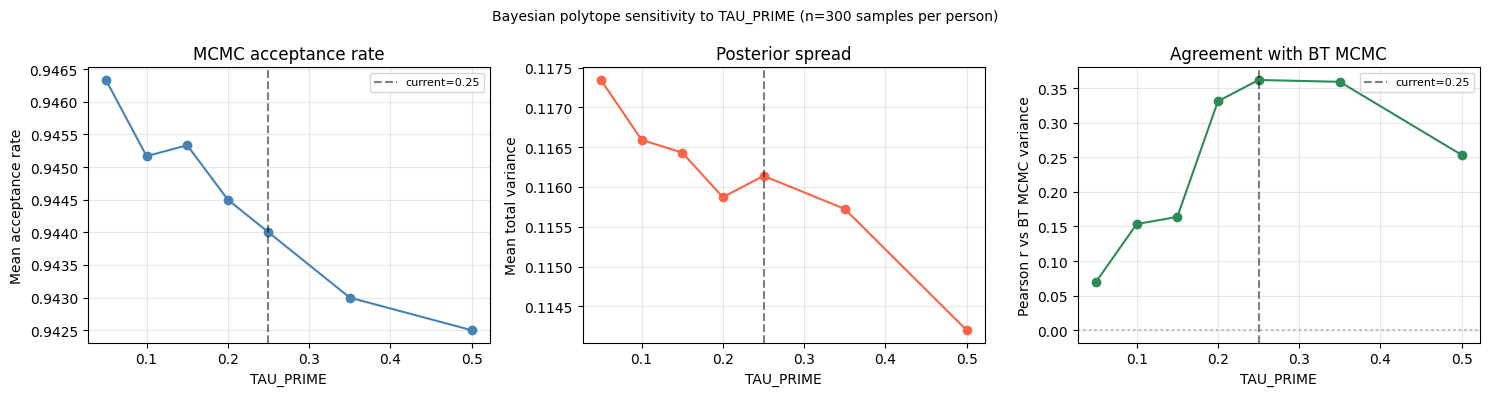

Saved kidney_tau_prime_sweep.png
Best r vs BT MCMC at TAU_PRIME=0.25  (r=0.362)


In [17]:
# ─── Cell 20b: TAU_PRIME sweep — Bayesian polytope sensitivity ────────────────
# Tests TAU_PRIME in [0.05, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50].
# For each value, runs BP MCMC on all persons (small n for speed) and reports:
#   - mean MCMC acceptance rate
#   - mean total posterior variance
#   - Pearson r vs BT MCMC total variance (requires cell 21 to have run first)

from scipy.stats import pearsonr as _pr

_TAU_PRIME_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50]
_N_SWEEP    = 300
_BURN_SWEEP = 200

def _response_probs_mc_tp(q, w, tau_prime, n_mc=50, rng=None):
    """Closed-form P(resp|q,w) with explicit tau_prime; n_mc/rng unused."""
    gaps, active = _frame_gaps_bald(q)
    delta = float(np.dot(gaps, w))
    r     = float(sum(w[j] * abs(gaps[j]) for j in active))
    if r < _TAU:
        return np.array([0.0, 0.0, 1.0, 0.0])
    th = tau_prime * r
    p_left  = float(_sigmoid(delta - th))
    p_right = float(_sigmoid(-(delta + th)))
    p_inc   = max(0.0, 1.0 - p_left - p_right)
    return np.array([p_left, p_right, 0.0, p_inc])

def _transcript_ll_tp(transcript, w, tau_prime, n_mc=30, rng=None):
    """Total log-likelihood with explicit tau_prime (closed form). n_mc/rng unused."""
    idx = {"left": 0, "right": 1, "indifferent": 2, "incomparable": 3}
    ll = 0.0
    for q, resp in transcript:
        probs = _response_probs_mc_tp(q, w, tau_prime)
        ll += np.log(max(probs[idx[resp]], 1e-10))
    return ll

def sample_bp_tp(transcript, tau_prime, n_samples=_N_SWEEP, burn_in=_BURN_SWEEP, n_mc=30, rng=None):
    """BP MCMC with a specific tau_prime."""
    if rng is None: rng = np.random.default_rng()
    w  = np.ones(_NDIM) / _NDIM
    ll = _transcript_ll_tp(transcript, w, tau_prime)
    samples, n_acc = [], 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        llp = _transcript_ll_tp(transcript, wp, tau_prime)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc += 1
        if step >= burn_in: samples.append(w.copy())
    return np.array(samples), n_acc / max(1, n_samples)

# ── Build transcripts once ─────────────────────────────────────────────────────
persons_sorted = sorted(df["personID"].unique(), key=str)
_transcripts = {}
for pid in persons_sorted:
    pid_str = str(pid)
    if feat_raw_df["personID"].astype(str).eq(pid_str).sum() == 0: continue
    person_rows = df[df["personID"] == pid].sort_values("comparison")
    try: q1 = build_q1(pid)
    except: continue
    qmap = {1: q1, 2: Q2, 3: Q3}
    _transcripts[pid] = [
        (_norm_query(qmap[int(row["comparison"])]), map_response(row))
        for _, row in person_rows.iterrows()
    ]

# ── Run sweep ────────────────────────────────────────────────────────────────────────
bt_pids  = [p for p in persons_sorted if p in _transcripts and p in bt_bald_results]
bt_v_ref = np.array([bt_bald_results[p]["total_var"] for p in bt_pids])

sweep_results = {}
print("{:>10}  {:>9}  {:>10}  {:>8}  {:>6}".format("tau_prime", "mean_acc", "mean_var", "r vs BT", "p"))

for tp in _TAU_PRIME_VALUES:
    accs, variances = [], []
    rng = np.random.default_rng(42)
    for pid in bt_pids:
        samp, acc = sample_bp_tp(_transcripts[pid], tp, rng=rng)
        accs.append(acc)
        variances.append(samp.var(axis=0).sum())
    bp_v = np.array(variances)
    r, p = _pr(bt_v_ref, bp_v) if len(bt_v_ref) > 2 else (float("nan"), float("nan"))
    sweep_results[tp] = {"mean_acc": np.mean(accs), "mean_var": np.mean(bp_v),
                          "vars": bp_v, "accs": np.array(accs), "persons": bt_pids}
    print("{:>10.2f}  {:>9.3f}  {:>10.5f}  {:>8.3f}  {:>6.3f}".format(tp, np.mean(accs), np.mean(bp_v), r, p))

# ── Plot ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
tps   = _TAU_PRIME_VALUES
accs_ = [float(sweep_results[t]["mean_acc"]) for t in tps]
vars_ = [float(sweep_results[t]["mean_var"]) for t in tps]
rs_   = [float(_pr(sweep_results[t]["vars"], bt_v_ref)[0]) for t in tps]
cur   = _TAU_PRIME

axes[0].plot(tps, accs_, "o-", color="steelblue")
axes[0].axvline(cur, color="k", linestyle="--", alpha=0.5, label="current={}".format(cur))
axes[0].set_xlabel("TAU_PRIME"); axes[0].set_ylabel("Mean acceptance rate")
axes[0].set_title("MCMC acceptance rate"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(tps, vars_, "o-", color="tomato")
axes[1].axvline(cur, color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("TAU_PRIME"); axes[1].set_ylabel("Mean total variance")
axes[1].set_title("Posterior spread"); axes[1].grid(True, alpha=0.3)

axes[2].plot(tps, rs_, "o-", color="seagreen")
axes[2].axvline(cur, color="k", linestyle="--", alpha=0.5, label="current={}".format(cur))
axes[2].set_xlabel("TAU_PRIME"); axes[2].set_ylabel("Pearson r vs BT MCMC variance")
axes[2].set_title("Agreement with BT MCMC"); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
axes[2].axhline(0, color="gray", linestyle=":", alpha=0.5)

plt.suptitle("Bayesian polytope sensitivity to TAU_PRIME (n=300 samples per person)", fontsize=10)
plt.tight_layout()
plt.savefig("kidney_tau_prime_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved kidney_tau_prime_sweep.png")
best_tp = tps[int(np.argmax(rs_))]
print("Best r vs BT MCMC at TAU_PRIME={:.2f}  (r={:.3f})".format(best_tp, max(rs_)))


  person  n_conf     τ_κ    t* (margin)   feas width    τ_lo    τ_hi
────────────────────────────────────────────────────────────────────────────────
   16234       0   0.000        +0.3333        1.000   0.000   1.000
   19857       2   0.380        +0.0868        1.000   0.000   1.000
   23405       3   1.000        +0.4000        1.000   0.000   1.000
   25171       1   0.000        -0.0000        1.000   0.000   1.000
   28789       1   0.080        +0.0293        1.000   0.000   1.000
   31772       1   0.500        +0.2222        1.000   0.000   1.000
   42828       2   0.600        +0.1976        1.000   0.000   1.000
   45865       3   1.000        +0.4286        1.000   0.000   1.000
   51283       1   0.320        +0.1467        1.000   0.000   1.000
   53826       1   0.440        +0.1270        1.000   0.000   1.000
   54338       0   0.000        +0.3333        1.000   0.000   1.000
   62264       1   0.300        +0.2074        1.000   0.000   1.000
   66158       3   1.0

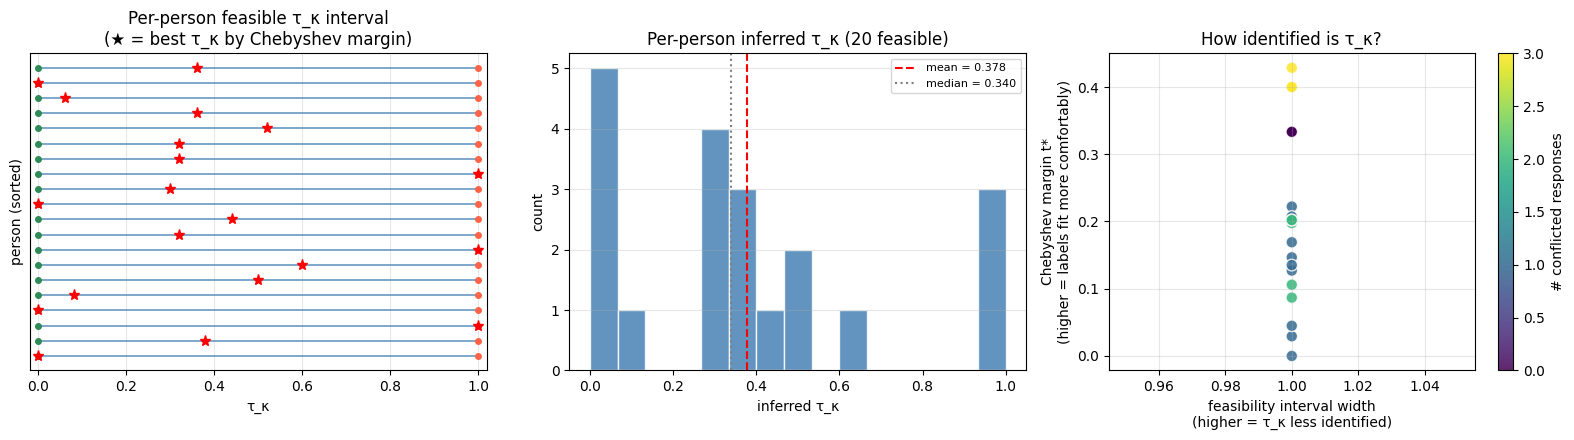

Saved kidney_polytope_tau_inference.png

Population-best τ_κ (median across feasible persons): 0.340


In [18]:
# ─── Cell 20c: Per-person LP-based τ_κ inference (paper-faithful) ───────────
# For each participant, sweep τ_κ ∈ [0, 1] and at each grid point solve:
#
#   (1) Strict feasibility LP — does there exist ω ∈ Δ⁵ admitting the labels?
#       Linear constraints (per response):
#         left  (≻):  -(φ - τ_κ|φ|)·ω ≤ 0       [g ≥ τ_κ S]
#         right (≺):   (φ + τ_κ|φ|)·ω ≤ 0       [-g ≥ τ_κ S]
#         incomp(⋈):   both directions of |g| ≤ τ_κ S
#       Plus simplex: ω ≥ 0, Σω = 1.
#
#   (2) Soft LP — minimize the max constraint violation s ≥ 0.
#
#   (3) Chebyshev center LP — maximise the slack t* to all constraints, i.e. find
#       the ω that comfortably fits all labels with the largest possible margin.
#       Only meaningful when t* ≥ 0 (otherwise the feasible polytope is empty).
#
# Each participant's inferred τ_κ is the grid value with the largest Chebyshev
# margin t*. Their feasibility interval [τ_lo, τ_hi] is the range of τ_κ for
# which strict feasibility holds — the *width* of this interval is our LP-side
# proxy for "how identified is τ_κ from this participant's 3 responses".

from scipy.optimize import linprog

def _build_constraints_kidney(transcript, tau_kappa):
    rows = []
    for q, resp in transcript:
        phi = q.patient_left.to_array() - q.patient_right.to_array()
        ap  = np.abs(phi)
        if   resp == 'left':         rows.append(-(phi - tau_kappa * ap))
        elif resp == 'right':        rows.append( (phi + tau_kappa * ap))
        elif resp == 'incomparable':
            rows.append( (phi - tau_kappa * ap))
            rows.append(-(phi + tau_kappa * ap))
    return np.array(rows) if rows else np.zeros((0, _NDIM))

def _feasibility_strict(transcript, tau_kappa, ndim=_NDIM):
    A_ub = _build_constraints_kidney(transcript, tau_kappa)
    if A_ub.shape[0] == 0:
        return True, np.ones(ndim) / ndim
    res = linprog(np.zeros(ndim), A_ub=A_ub, b_ub=np.zeros(len(A_ub)),
                  A_eq=np.ones((1, ndim)), b_eq=np.array([1.0]),
                  bounds=[(0, None)] * ndim, method='highs')
    return res.success, (res.x if res.success else None)

def _feasibility_soft(transcript, tau_kappa, ndim=_NDIM):
    """Minimize max constraint violation s ≥ 0 over (ω, s). Returns (s*, ω)."""
    A = _build_constraints_kidney(transcript, tau_kappa)
    n = len(A)
    if n == 0:
        return 0.0, np.ones(ndim) / ndim
    A_ub = np.column_stack([A, -np.ones(n)])
    A_eq = np.zeros((1, ndim + 1)); A_eq[0, :ndim] = 1
    res = linprog(np.r_[np.zeros(ndim), 1.0],
                  A_ub=A_ub, b_ub=np.zeros(n),
                  A_eq=A_eq, b_eq=np.array([1.0]),
                  bounds=[(0, None)] * ndim + [(0, None)],
                  method='highs')
    if not res.success:
        return np.inf, None
    return float(res.fun), res.x[:ndim]

def _chebyshev_center(transcript, tau_kappa, ndim=_NDIM):
    """Find ω that maximises margin to all constraints. Solves: max t s.t. A·ω + t·1 ≤ 0, ω∈Δ.
    Only meaningful if t* ≥ 0."""
    A = _build_constraints_kidney(transcript, tau_kappa)
    n = len(A)
    if n == 0:
        return 1.0, np.ones(ndim) / ndim
    A_ub = np.column_stack([A,  np.ones(n)])
    A_eq = np.zeros((1, ndim + 1)); A_eq[0, :ndim] = 1
    res = linprog(np.r_[np.zeros(ndim), -1.0],
                  A_ub=A_ub, b_ub=np.zeros(n),
                  A_eq=A_eq, b_eq=np.array([1.0]),
                  bounds=[(0, None)] * ndim + [(None, None)],
                  method='highs')
    if not res.success:
        return -np.inf, None
    return float(-res.fun), res.x[:ndim]


# ── Rebuild _transcripts dict defensively (in case it was wiped) ────────────
if '_transcripts' not in dir() or not _transcripts:
    _transcripts = {}
    for pid in sorted(df['personID'].unique(), key=str):
        if feat_raw_df['personID'].astype(str).eq(str(pid)).sum() == 0: continue
        person_rows = df[df['personID'] == pid].sort_values('comparison')
        try: q1 = build_q1(pid)
        except: continue
        qmap = {1: q1, 2: Q2, 3: Q3}
        _transcripts[pid] = [
            (_norm_query(qmap[int(row['comparison'])]), map_response(row))
            for _, row in person_rows.iterrows()
        ]


# ── Per-person sweep over τ_κ grid ──────────────────────────────────────────
TAU_GRID = np.linspace(0.0, 1.0, 51)
person_tau = {}

print(f'{"person":>8}  {"n_conf":>6}  {"τ_κ":>6}  {"t* (margin)":>13}  {"feas width":>11}  {"τ_lo":>6}  {"τ_hi":>6}')
print('─' * 80)

for pid in sorted(_transcripts.keys(), key=str):
    tr = _transcripts[pid]
    feas_flags  = []
    soft_viol   = []
    margins     = []
    omegas      = []
    for tk in TAU_GRID:
        ok, w_strict = _feasibility_strict(tr, tk)
        s_soft, _    = _feasibility_soft(tr, tk)
        if ok:
            t_star, w_cheb = _chebyshev_center(tr, tk)
            omegas.append(w_cheb)
        else:
            t_star, w_cheb = -np.inf, None
            omegas.append(None)
        feas_flags.append(ok)
        soft_viol.append(s_soft)
        margins.append(t_star)
    feas_flags = np.array(feas_flags)
    margins    = np.array(margins)
    soft_viol  = np.array(soft_viol)
    feas_idx = np.where(feas_flags)[0]

    if len(feas_idx) > 0:
        # Best τ_κ by Chebyshev margin (most slack to all constraints)
        best_idx       = feas_idx[np.argmax(margins[feas_idx])]
        tau_inferred   = float(TAU_GRID[best_idx])
        margin         = float(margins[best_idx])
        omega_inferred = omegas[best_idx]
        tau_lo         = float(TAU_GRID[feas_idx[0]])
        tau_hi         = float(TAU_GRID[feas_idx[-1]])
        feas_width     = tau_hi - tau_lo
    else:
        # No τ_κ admits strict feasibility — fall back to soft-min violation
        soft_idx       = int(np.argmin(soft_viol))
        tau_inferred   = float(TAU_GRID[soft_idx])
        margin         = float('nan')
        omega_inferred = None
        tau_lo         = float('nan')
        tau_hi         = float('nan')
        feas_width     = float('nan')

    n_conf = sum(1 for _, r in tr if r == 'incomparable')
    person_tau[pid] = {
        'tau':         tau_inferred,
        'margin':      margin,
        'omega':       omega_inferred,
        'tau_lo':      tau_lo,
        'tau_hi':      tau_hi,
        'feas_width':  feas_width,
        'feas_flags':  feas_flags.copy(),
        'margins':     margins.copy(),
        'soft_viol':   soft_viol.copy(),
        'n_conf':      n_conf,
    }

    margin_str = f'{margin:>+13.4f}' if not np.isnan(margin) else f'{"INFEAS":>13s}'
    width_str  = f'{feas_width:>11.3f}' if not np.isnan(feas_width) else f'{"—":>11s}'
    lo_str     = f'{tau_lo:>6.3f}' if not np.isnan(tau_lo) else f'{"—":>6s}'
    hi_str     = f'{tau_hi:>6.3f}' if not np.isnan(tau_hi) else f'{"—":>6s}'
    print(f'{pid:>8}  {n_conf:>6d}  {tau_inferred:>6.3f}  {margin_str}  {width_str}  {lo_str}  {hi_str}')

valid = [v for v in person_tau.values() if not np.isnan(v['margin'])]
infeasible = [pid for pid, v in person_tau.items() if np.isnan(v['margin'])]
print()
print(f'Population-level τ_κ summary  ({len(valid)} of {len(person_tau)} strictly feasible)')
print('─' * 60)
if valid:
    taus = np.array([v['tau']         for v in valid])
    mrgs = np.array([v['margin']      for v in valid])
    wids = np.array([v['feas_width']  for v in valid])
    print(f'  τ_κ          mean = {taus.mean():.3f}    median = {np.median(taus):.3f}    range = [{taus.min():.3f}, {taus.max():.3f}]')
    print(f'  margin t*    mean = {mrgs.mean():.4f}    median = {np.median(mrgs):.4f}    range = [{mrgs.min():.4f}, {mrgs.max():.4f}]')
    print(f'  feas width   mean = {wids.mean():.3f}    median = {np.median(wids):.3f}    range = [{wids.min():.3f}, {wids.max():.3f}]')
if infeasible:
    print(f'  Infeasible persons (no τ_κ admits labels strictly): {infeasible}')

# ── Plots ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: per-person feasibility intervals
ax = axes[0]
person_intervals = sorted(person_tau.items(),
    key=lambda kv: (np.nan_to_num(kv[1]['tau_lo'], nan=2.0),
                    np.nan_to_num(kv[1]['tau_hi'], nan=2.0)))
for i, (pid, v) in enumerate(person_intervals):
    if not np.isnan(v['tau_lo']):
        ax.plot([v['tau_lo'], v['tau_hi']], [i, i], '-', color='steelblue', lw=1.4, alpha=0.7)
        ax.plot([v['tau_lo']], [i], 'o', color='seagreen', markersize=4)
        ax.plot([v['tau_hi']], [i], 'o', color='tomato',   markersize=4)
        ax.plot([v['tau']],     [i], '*', color='red',      markersize=8)
    else:
        ax.plot([0, 1], [i, i], ':', color='lightgray', lw=0.5)
ax.set_xlabel('τ_κ'); ax.set_ylabel('person (sorted)')
ax.set_yticks([]); ax.set_xlim(-0.02, 1.02)
ax.set_title('Per-person feasible τ_κ interval\n(★ = best τ_κ by Chebyshev margin)')
ax.grid(True, alpha=0.3)

# Panel 2: histogram of inferred τ_κ
ax = axes[1]
taus_hist = [v['tau'] for v in valid]
ax.hist(taus_hist, bins=15, color='steelblue', alpha=0.85, edgecolor='white')
ax.axvline(np.mean(taus_hist),   color='red',  ls='--', label=f'mean = {np.mean(taus_hist):.3f}')
ax.axvline(np.median(taus_hist), color='gray', ls=':',  label=f'median = {np.median(taus_hist):.3f}')
ax.set_xlabel('inferred τ_κ'); ax.set_ylabel('count')
ax.set_title(f'Per-person inferred τ_κ ({len(valid)} feasible)')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Panel 3: Chebyshev margin vs feasibility width (scatter)
ax = axes[2]
mrgs = [v['margin']     for v in valid]
wids = [v['feas_width'] for v in valid]
nconf = [v['n_conf']    for v in valid]
sc = ax.scatter(wids, mrgs, c=nconf, cmap='viridis', s=70, alpha=0.85, edgecolor='white')
plt.colorbar(sc, ax=ax, label='# conflicted responses')
ax.set_xlabel('feasibility interval width\n(higher = τ_κ less identified)')
ax.set_ylabel('Chebyshev margin t*\n(higher = labels fit more comfortably)')
ax.set_title('How identified is τ_κ?')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kidney_polytope_tau_inference.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved kidney_polytope_tau_inference.png')

# Backward-compat: also expose a single population-best τ_κ
if valid:
    tau_kappa_polytope_kidney = float(np.median([v['tau'] for v in valid]))
    print(f'\nPopulation-best τ_κ (median across feasible persons): {tau_kappa_polytope_kidney:.3f}')
else:
    tau_kappa_polytope_kidney = 0.25


In [19]:
# ─── Cell 21b: BT MCMC — conflicted responses treated as decisive ─────────────
# Same hit-and-run MCMC as cell 21, but includes conflicted responses using the
# participant's reported choice (A/B) as the label rather than dropping them.

bt_decisive_results = {}

for pid in sorted(df["personID"].unique()):
    pid_str = str(pid)
    if feat_raw_df["personID"].astype(str).eq(pid_str).sum() == 0:
        continue

    person_rows = df[df["personID"] == pid].sort_values("comparison")
    try:
        q1 = build_q1(pid)
    except Exception as e:
        print(f"{pid:>8}  ERROR: {e}"); continue

    query_map = {1: q1, 2: Q2, 3: Q3}
    rng = np.random.default_rng(int(pid_str[-4:]) if pid_str.isdigit() else 0)

    phis_all, ys_all = [], []
    for _, row in person_rows.iterrows():
        comp   = int(row["comparison"])
        q_norm = _norm_query(query_map[comp])
        choice = row["choice"]
        if choice not in ("A", "B"): continue
        phis_all.append(q_norm.patient_left.to_array() - q_norm.patient_right.to_array())
        ys_all.append(1.0 if choice == "A" else 0.0)

    phis_arr = np.array(phis_all) if phis_all else np.zeros((0, _NDIM))
    ys_arr   = np.array(ys_all)   if ys_all   else np.zeros(0)

    bt_samples, acc = sample_bt_mcmc(phis_arr, ys_arr, n_samples=N_BT_MC,
                                      burn_in=BURN_IN, rng=rng)
    bt_decisive_results[pid] = {
        "samples":   bt_samples,
        "mean":      bt_samples.mean(axis=0),
        "std":       bt_samples.std(axis=0),
        "total_var": bt_samples.var(axis=0).sum(),
        "acc":       acc,
        "n_obs":     len(phis_all),
    }

print(f"{'person':>8}  {'n_obs':>5}  {'bt_drop_var':>11}  {'bt_decisive_var':>15}  {'bp_var':>8}")
for pid in sorted(bt_decisive_results):
    bv_d = bt_bald_results[pid]["total_var"]    if pid in bt_bald_results    else float("nan")
    bv_c = bt_decisive_results[pid]["total_var"]
    bv_p = bayes_poly_results[pid]["total_var"] if pid in bayes_poly_results else float("nan")
    n    = bt_decisive_results[pid]["n_obs"]
    print(f"{pid:>8}  {n:>5}  {bv_d:>11.5f}  {bv_c:>15.5f}  {bv_p:>8.5f}")

print(f"\nDone. {len(bt_decisive_results)} persons.")


  person  n_obs  bt_drop_var  bt_decisive_var    bp_var
   16234      3      0.12589          0.12668   0.13130
   19857      3      0.11799          0.12039   0.11152
   23405      3      0.13114          0.11403   0.12557
   25171      3      0.13031          0.11728   0.11260
   28789      3      0.12766          0.10973   0.11317
   31772      3      0.11732          0.14272   0.13259
   42828      3      0.13046          0.15243   0.12239
   45865      3      0.12846          0.12882   0.11042
   51283      3      0.12202          0.09835   0.09578
   53826      3      0.12746          0.14876   0.12779
   54338      3      0.13820          0.11468   0.11463
   62264      3      0.11594          0.13384   0.12107
   66158      3      0.13578          0.13652   0.12408
   68470      3      0.13713          0.12131   0.10043
   74211      3      0.11577          0.14293   0.12591
   76769      3      0.12794          0.12336   0.11661
   80894      3      0.15280          0.15498   

## Part 1 — Value of using conflict

This section asks: **does explicitly modelling conflicted responses help?**

We compare three ways to handle the same set of pairwise responses:

- **Utilize-Indecision** (Multi-Frame Polytope) — uses *all* responses; conflicted responses contribute as *incomparable* under the closed-form 4-tier likelihood.
- **Ignore-Indecision** (BT, drop conflict) — drops conflicted queries entirely. Same BT logistic likelihood, fewer datapoints.
- **Force-Decision** (BT, force decision) — keeps conflicted queries but uses the participant's reported A/B choice as a hard label.

All three use the same hit-and-run MCMC on the simplex with a uniform prior. The comparison isolates the *modelling* of indecision: same data, three different ways to use the conflicted responses.


BP vs BT-drop:      r=-0.018  p=0.939
BP vs BT-decisive:  r=0.736  p=0.000
BT-drop vs BT-dec:  r=0.089  p=0.709


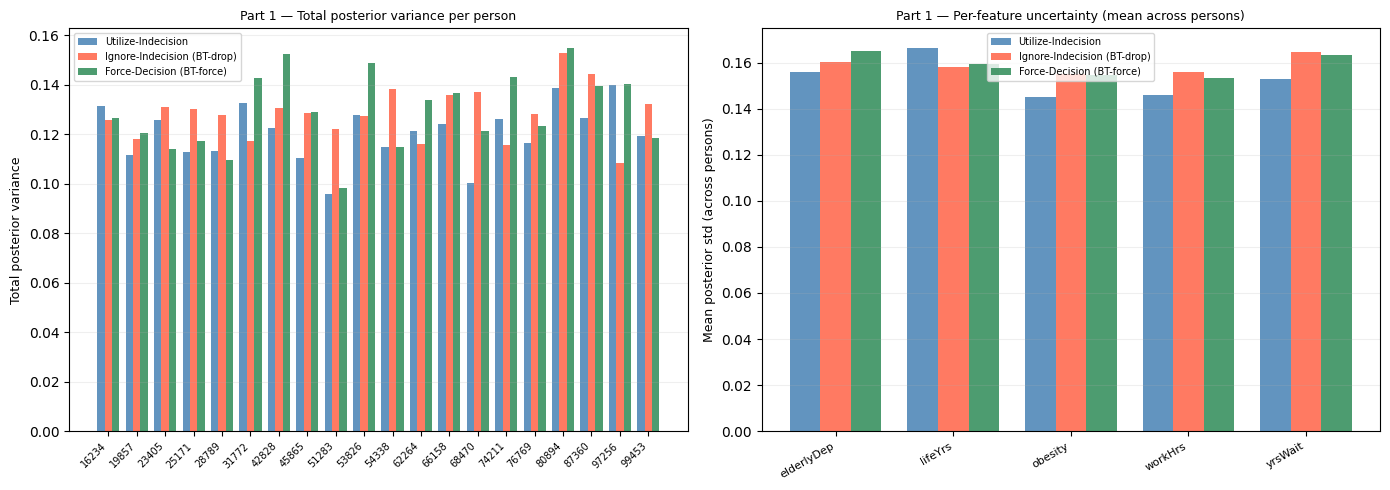

Saved kidney_bayes_poly_vs_bt_bald.png


In [20]:
# ─── Cell 22: Posterior variance — Bayesian polytope vs BT MCMC ──────────────

persons  = sorted(bayes_poly_results.keys())
bp_vars  = np.array([bayes_poly_results[p]["total_var"]   for p in persons])
btd_vars = np.array([bt_bald_results[p]["total_var"]      for p in persons])
btc_vars = np.array([bt_decisive_results[p]["total_var"]  for p in persons])

bp_std   = np.array([bayes_poly_results[p]["std"]         for p in persons])
btd_std  = np.array([bt_bald_results[p]["std"]            for p in persons])
btc_std  = np.array([bt_decisive_results[p]["std"]        for p in persons])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: total variance per person ───────────────────────────────────────────────
ax = axes[0]
x, bw = np.arange(len(persons)), 0.26
ax.bar(x - bw,  bp_vars,  width=bw, color="steelblue", alpha=0.85, label="Utilize-Indecision")
ax.bar(x,       btd_vars, width=bw, color="tomato",    alpha=0.85, label="Ignore-Indecision (BT-drop)")
ax.bar(x + bw,  btc_vars, width=bw, color="seagreen",  alpha=0.85, label="Force-Decision (BT-force)")
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in persons], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Total posterior variance", fontsize=9)
ax.set_title("Part 1 — Total posterior variance per person", fontsize=9)
ax.legend(fontsize=7); ax.grid(True, alpha=0.2, axis="y")

# ── Right: per-feature std averaged across persons ──────────────────────────
ax3 = axes[1]
feat_labels = ["elderlyDep", "lifeYrs", "obesity", "workHrs", "yrsWait"]
xf, bw3 = np.arange(len(feat_labels)), 0.26
ax3.bar(xf - bw3, bp_std.mean(axis=0),  width=bw3, color="steelblue", alpha=0.85, label="Utilize-Indecision")
ax3.bar(xf,       btd_std.mean(axis=0), width=bw3, color="tomato",    alpha=0.85, label="Ignore-Indecision (BT-drop)")
ax3.bar(xf + bw3, btc_std.mean(axis=0), width=bw3, color="seagreen",  alpha=0.85, label="Force-Decision (BT-force)")
ax3.set_xticks(xf)
ax3.set_xticklabels(feat_labels, rotation=30, ha="right", fontsize=8)
ax3.set_ylabel("Mean posterior std (across persons)", fontsize=9)
ax3.set_title("Part 1 — Per-feature uncertainty (mean across persons)", fontsize=9)
ax3.legend(fontsize=7); ax3.grid(True, alpha=0.2, axis="y")

from scipy.stats import pearsonr
r1, p1 = pearsonr(btd_vars, bp_vars)
r2, p2 = pearsonr(btc_vars, bp_vars)
r3, p3 = pearsonr(btd_vars, btc_vars)
print("BP vs BT-drop:      r={:.3f}  p={:.3f}".format(r1, p1))
print("BP vs BT-decisive:  r={:.3f}  p={:.3f}".format(r2, p2))
print("BT-drop vs BT-dec:  r={:.3f}  p={:.3f}".format(r3, p3))

# plt.suptitle(
#     "\n"
#     "All methods use hit-and-run MCMC on the simplex",
#     fontsize=10
# )
plt.tight_layout()
plt.savefig("kidney_bayes_poly_vs_bt_bald.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved kidney_bayes_poly_vs_bt_bald.png")


## Part 2 — Comparison against baselines that also model incomparability

This section asks: **how does Utilize-Indecision compare to other models that already allow ties / incomparability?**

We compare three baselines, all trained on the same full set of responses (conflicted → incomparable):

- **Utilize-Indecision** (Multi-Frame Polytope) — our method.
- **Rao-Kupper** ($\theta \geq 1$) — classic tie extension of Bradley-Terry. $P(\text{tie}) = (\theta^2-1) / [(1+\theta e^{-\Delta})(1+\theta e^{\Delta})]$. Reduces to BT at $\theta=1$.
- **Davidson** ($\nu \geq 0$) — alternative tie extension that preserves the Luce odds ratio $P(\text{left})/P(\text{right}) = e^\Delta$. $P(\text{tie}) = \nu / Z$. Reduces to BT at $\nu=0$.

All three share the same simplex prior, hit-and-run MCMC, and Block-Gibbs update for the tie parameter; posterior variance is reported on $\omega$ only.


  person   bp_acc  rk_accω  dv_accω      bp_var     rk_varω     dv_varω       rk_θ      dv_ν
   16234    0.950    0.960    0.958     0.11155     0.12450     0.14189      1.614     1.026
   19857    0.910    0.970    0.986     0.10433     0.12442     0.12144      4.806     4.414
   23405    0.932    0.994    1.000     0.11074     0.11200     0.12952      7.766     7.949
   25171    0.894    0.982    0.968     0.07058     0.12765     0.15350      2.374     2.077
   28789    0.970    0.970    0.986     0.16263     0.11124     0.14482      3.229     2.697
   31772    0.976    0.952    0.966     0.13493     0.11702     0.16487      4.137     3.707
   42828    0.936    0.964    0.980     0.11746     0.13626     0.12622      4.421     7.553
   45865    0.930    0.998    1.000     0.11921     0.15820     0.12823      6.893     6.120
   51283    0.976    0.974    0.990     0.11297     0.12235     0.13063      2.331     4.309
   53826    0.894    0.958    0.976     0.11125     0.12867     0.1308

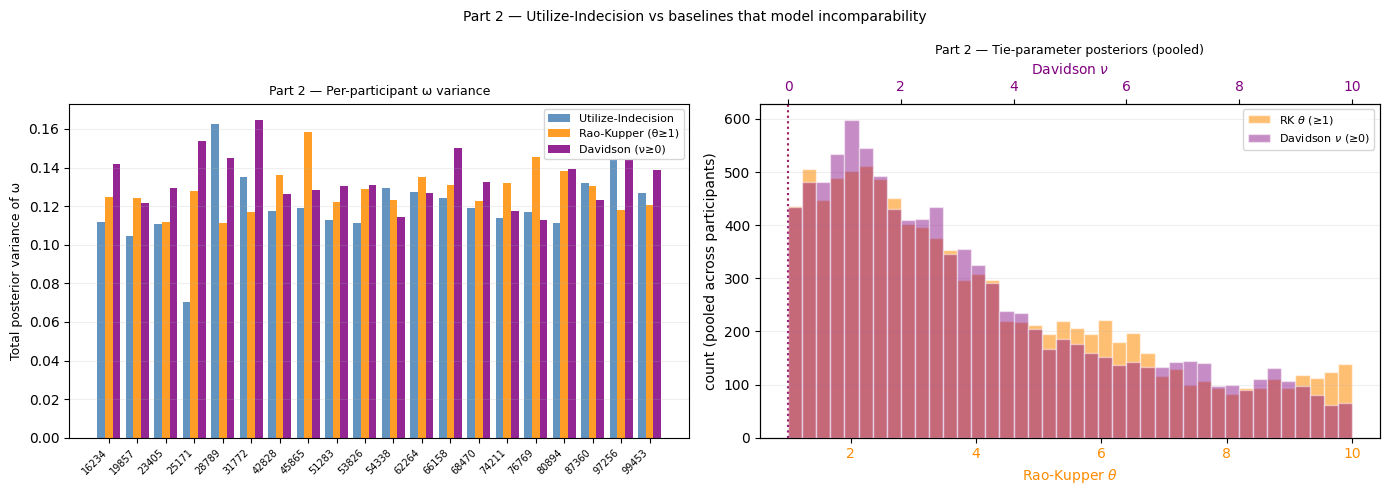

Saved kidney_rk_benchmark.png


In [21]:
# ─── Cell 24: Part 2 — BP vs Rao-Kupper vs Davidson ─────────────────────────
# All three pipelines trained on the full transcript; conflicted → incomparable.
# Variance measured on ω only (tie parameters θ, ν reported separately).

N_RK       = 500
N_RK_BURN  = 500

bp_full_results = {}   # Multi-Frame Polytope
rk_results      = {}   # Rao-Kupper
dv_results      = {}   # Davidson

print("{:>8}  {:>7}  {:>7}  {:>7}  {:>10}  {:>10}  {:>10}  {:>9}  {:>8}".format(
    "person", "bp_acc", "rk_accω", "dv_accω", "bp_var", "rk_varω", "dv_varω", "rk_θ", "dv_ν"))

for pid in sorted(df["personID"].unique(), key=str):
    pid_str = str(pid)
    if feat_raw_df["personID"].astype(str).eq(pid_str).sum() == 0:
        continue
    person_rows = df[df["personID"] == pid].sort_values("comparison")
    try:
        q1 = build_q1(pid)
    except Exception as e:
        print("{:>8}  ERROR: {}".format(pid, e)); continue

    qmap = {1: q1, 2: Q2, 3: Q3}
    rng  = np.random.default_rng(int(pid_str[-4:]) if pid_str.isdigit() else 0)

    transcript_full = []
    phis, responses = [], []
    for _, row in person_rows.iterrows():
        comp   = int(row["comparison"])
        q_norm = _norm_query(qmap[comp])
        resp   = map_response(row)
        transcript_full.append((q_norm, resp))
        phis.append(q_norm.patient_left.to_array() - q_norm.patient_right.to_array())
        responses.append(resp)
    phis_arr = np.array(phis)

    # Multi-Frame Polytope
    samps_bp, bp_acc = sample_bayes_polytope_posterior(
        transcript_full, n_samples=N_RK, burn_in=N_RK_BURN, n_mc=50,
        rng=np.random.default_rng(rng.integers(1 << 31)))
    bp_var = float(samps_bp.var(axis=0).sum())
    bp_full_results[pid] = {"samples": samps_bp, "total_var": bp_var, "acc": bp_acc}

    # Rao-Kupper (θ ≥ 1)
    samps_rk, acc_w_rk, acc_th_rk = sample_rk_mcmc(
        phis_arr, responses, n_samples=N_RK, burn_in=N_RK_BURN,
        rng=np.random.default_rng(rng.integers(1 << 31)))
    omega_rk = samps_rk[:, :_NDIM]
    theta_rk = samps_rk[:,  _NDIM]
    rk_var   = float(omega_rk.var(axis=0).sum())
    rk_results[pid] = {
        "samples": samps_rk, "omega_samps": omega_rk, "theta_samps": theta_rk,
        "total_var": rk_var, "theta_mean": float(theta_rk.mean()),
        "acc_w": acc_w_rk, "acc_th": acc_th_rk,
    }

    # Davidson (ν ≥ 0)
    samps_dv, acc_w_dv, acc_nu_dv = sample_davidson_mcmc(
        phis_arr, responses, n_samples=N_RK, burn_in=N_RK_BURN,
        rng=np.random.default_rng(rng.integers(1 << 31)))
    omega_dv = samps_dv[:, :_NDIM]
    nu_dv    = samps_dv[:,  _NDIM]
    dv_var   = float(omega_dv.var(axis=0).sum())
    dv_results[pid] = {
        "samples": samps_dv, "omega_samps": omega_dv, "nu_samps": nu_dv,
        "total_var": dv_var, "nu_mean": float(nu_dv.mean()),
        "acc_w": acc_w_dv, "acc_nu": acc_nu_dv,
    }

    print("{:>8}  {:>7.3f}  {:>7.3f}  {:>7.3f}  {:>10.5f}  {:>10.5f}  {:>10.5f}  {:>9.3f}  {:>8.3f}".format(
        pid, bp_acc, acc_w_rk, acc_w_dv, bp_var, rk_var, dv_var,
        float(theta_rk.mean()), float(nu_dv.mean())))

# ── Aggregate ────────────────────────────────────────────────────────────────
persons_p2 = sorted(rk_results.keys(), key=str)
bp_vars_p2 = np.array([bp_full_results[p]["total_var"] for p in persons_p2])
rk_vars    = np.array([rk_results[p]["total_var"]     for p in persons_p2])
dv_vars    = np.array([dv_results[p]["total_var"]     for p in persons_p2])
theta_means = np.array([rk_results[p]["theta_mean"]   for p in persons_p2])
nu_means    = np.array([dv_results[p]["nu_mean"]      for p in persons_p2])

print("\n" + "="*64)
print("Part 2 — Baselines that model incomparability  ({} participants)".format(len(persons_p2)))
print("="*64)
print("{:<34} {:>9}  {:>9}  {:>9}".format("Metric", "Utilize", "Rao-Kupp", "Davidson"))
print("-"*64)
print("{:<34} {:>9.5f}  {:>9.5f}  {:>9.5f}".format(
    "Mean total var (ω)",   bp_vars_p2.mean(), rk_vars.mean(), dv_vars.mean()))
print("{:<34} {:>9.5f}  {:>9.5f}  {:>9.5f}".format(
    "Median total var (ω)", np.median(bp_vars_p2), np.median(rk_vars), np.median(dv_vars)))
print("{:<34} {:>9}  {:>9.3f}  {:>9.3f}".format(
    "Mean tie parameter",   "—", theta_means.mean(), nu_means.mean()))
print("="*64)
print("Utilize wins vs RK:        {} / {}".format((bp_vars_p2 < rk_vars).sum(),  len(persons_p2)))
print("Utilize wins vs Davidson:  {} / {}".format((bp_vars_p2 < dv_vars).sum(),  len(persons_p2)))

# ── Plot: per-participant variance (3 bars) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x, bw = np.arange(len(persons_p2)), 0.27
ax.bar(x - bw, bp_vars_p2, width=bw, color="steelblue",  alpha=0.85, label="Utilize-Indecision")
ax.bar(x,      rk_vars,    width=bw, color="darkorange", alpha=0.85, label="Rao-Kupper (θ≥1)")
ax.bar(x + bw, dv_vars,    width=bw, color="purple",     alpha=0.85, label="Davidson (ν≥0)")
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in persons_p2], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Total posterior variance of ω", fontsize=9)
ax.set_title("Part 2 — Per-participant ω variance", fontsize=9)
ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis="y")

# ── Plot: tie-parameter posteriors aggregated across participants ────────────
ax2 = axes[1]
all_theta = np.concatenate([rk_results[p]["theta_samps"] for p in persons_p2])
all_nu    = np.concatenate([dv_results[p]["nu_samps"]    for p in persons_p2])
ax2_twin  = ax2.twiny()
ax2.hist(all_theta, bins=40, color="darkorange", alpha=0.55, edgecolor="white", label=r"RK $\theta$ (≥1)")
ax2_twin.hist(all_nu, bins=40, color="purple",   alpha=0.45, edgecolor="white", label=r"Davidson $\nu$ (≥0)")
ax2.axvline(1.0, color="darkorange", ls=":", alpha=0.8)
ax2_twin.axvline(0.0, color="purple", ls=":", alpha=0.8)
ax2.set_xlabel(r"Rao-Kupper $\theta$",  color="darkorange")
ax2_twin.set_xlabel(r"Davidson $\nu$", color="purple")
ax2.set_ylabel("count (pooled across participants)")
ax2.set_title("Part 2 — Tie-parameter posteriors (pooled)", fontsize=9)
ax2.tick_params(axis="x", labelcolor="darkorange")
ax2_twin.tick_params(axis="x", labelcolor="purple")
ax2.grid(True, alpha=0.2, axis="y")

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

plt.suptitle(
    "Part 2 — Utilize-Indecision vs baselines that model incomparability",
    fontsize=10)
plt.tight_layout()
plt.savefig("kidney_rk_benchmark.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved kidney_rk_benchmark.png")


## Summary statistics — Utilize-Indecision vs all baselines

Aggregated over 20 kidney participants (3 responses each). For each method we report:

- **Mean / median total ω-variance** $\sum_k \text{Var}[\omega_k]$ across participants — lower is tighter.
- **Mean predictive accuracy** on each participant's decisive (A/B) responses (in-sample, directional).
- **BP wins** — number of participants where Utilize-Indecision has lower posterior variance than the baseline.
- **Mean variance reduction** — average of $1 - \text{Var}_{\text{BP}} / \text{Var}_{\text{baseline}}$ across participants. Positive means BP is on average tighter than the baseline; negative means BP is more diffuse.

Note: BP results from cell 21 (`bayes_poly_results`) are used as the canonical Utilize-Indecision run; cell 24's `bp_full_results` is an independent re-run with a different seed and may differ slightly.


In [22]:
# ─── Summary stats: kidney across all 5 methods ─────────────────────────────
import numpy as np

# Use the BP results from cell 21 (bayes_poly_results) as canonical.
persons = sorted([p for p in bayes_poly_results.keys()
                  if p in bt_bald_results
                  and p in bt_decisive_results
                  and p in rk_results
                  and p in dv_results], key=str)
n_p = len(persons)

# Helper: compute directional predictive accuracy on a participant's decisive responses
# given a posterior mean omega.
def _person_acc(pid, omega):
    rows = df[df["personID"] == pid].sort_values("comparison")
    correct, total = 0, 0
    qmap_cache = {1: build_q1(pid), 2: Q2, 3: Q3}
    for _, row in rows.iterrows():
        if row["choice"] not in ("A", "B"):
            continue
        q_norm = _norm_query(qmap_cache[int(row["comparison"])])
        phi    = q_norm.patient_left.to_array() - q_norm.patient_right.to_array()
        pred_A = (phi @ omega) > 0
        actual_A = (row["choice"] == "A")
        correct += int(pred_A == actual_A)
        total   += 1
    return (correct / total) if total > 0 else float("nan")

def _omega_mean(result):
    """Pull posterior mean ω out of either a BP/BT result (key 'mean') or RK/DV (omega_samps)."""
    if "omega_samps" in result:
        return result["omega_samps"].mean(axis=0)
    if "mean" in result:
        return result["mean"]
    return result["samples"][:, :_NDIM].mean(axis=0)

methods = [
    ('Utilize-Indecision (BP)',     bayes_poly_results),
    ('Ignore-Indecision (BT-drop)', bt_bald_results),
    ('Force-Decision (BT-force)',   bt_decisive_results),
    ('Rao-Kupper (θ≥1)',            rk_results),
    ('Davidson (ν≥0)',              dv_results),
]

bp_var_arr = np.array([bayes_poly_results[p]["total_var"] for p in persons])
bp_acc_arr = np.array([_person_acc(p, _omega_mean(bayes_poly_results[p])) for p in persons])

# ── Absolute per-method aggregates ──────────────────────────────────────────
print(f'Kidney — {n_p} participants × 3 responses each')
print('═' * 100)
print(f'{"Method":30s}  {"mean var":>10s}  {"med var":>10s}  {"mean acc":>10s}  {"BP wins":>10s}  {"Δvar mean%":>11s}')
print('─' * 100)

method_var_arrays = {}
for label, results in methods:
    var_arr = np.array([results[p]["total_var"] for p in persons])
    acc_arr = np.array([_person_acc(p, _omega_mean(results[p])) for p in persons])
    method_var_arrays[label] = var_arr

    if label.startswith('Utilize-Indecision'):
        wins_str   = '— / —'
        red_pct_str = '—'
    else:
        wins_n     = int((bp_var_arr < var_arr).sum())
        wins_str   = f'{wins_n} / {n_p}'
        # mean variance reduction: 1 - Var_BP/Var_baseline (clipped to avoid div-by-zero)
        red_arr    = 1.0 - bp_var_arr / np.where(var_arr > 0, var_arr, np.nan)
        red_pct_str = f'{np.nanmean(red_arr) * 100:+.1f}%'

    print(f'{label:30s}  {var_arr.mean():>10.5f}  {np.median(var_arr):>10.5f}  '
          f'{acc_arr.mean():>10.1%}  {wins_str:>10s}  {red_pct_str:>11s}')

# ── BP head-to-head with each baseline (paired stats) ───────────────────────
print(f'\nUtilize-Indecision (BP) vs each baseline — paired across participants')
print('═' * 100)
print(f'{"Comparison":40s}  {"BP wins":>10s}  {"med Δvar%":>11s}  {"mean Δvar%":>12s}  {"BP-acc - X-acc":>16s}')
print('─' * 100)
for label, results in methods[1:]:
    var_arr = method_var_arrays[label]
    acc_arr = np.array([_person_acc(p, _omega_mean(results[p])) for p in persons])
    wins_n  = int((bp_var_arr < var_arr).sum())
    red_arr = 1.0 - bp_var_arr / np.where(var_arr > 0, var_arr, np.nan)
    med_red = np.nanmedian(red_arr) * 100
    mean_red = np.nanmean(red_arr) * 100
    acc_diff = (bp_acc_arr - acc_arr).mean() * 100
    print(f'{"BP vs " + label:40s}  {wins_n:>5d} / {n_p:<3d}  {med_red:>+10.1f}%  {mean_red:>+11.1f}%  {acc_diff:>+15.1f}%')

# ── Conflict-rate stratification: does BP help more on high-conflict participants? ──
print(f'\nVariance reduction (BP vs each baseline) by per-participant conflict count')
print('═' * 100)
n_conf_per_person = df.groupby("personID")["conflicted"].sum().to_dict()
strata = [(0, '0 conflicts'), (1, '1 conflict'), (2, '2 conflicts'), (3, '3 conflicts')]
print(f'{"Stratum":15s}  {"n":>3s}  {"Δvar(BT-drop)":>14s}  {"Δvar(BT-force)":>15s}  {"Δvar(RK)":>10s}  {"Δvar(DV)":>10s}')
print('─' * 100)
for n_c, label_str in strata:
    pids_in_stratum = [p for p in persons if n_conf_per_person.get(p, 0) == n_c]
    if not pids_in_stratum: continue
    n_in = len(pids_in_stratum)
    idx = [persons.index(p) for p in pids_in_stratum]
    bp_v = bp_var_arr[idx]
    cells = []
    for label, results in methods[1:]:
        v = method_var_arrays[label][idx]
        red = (1.0 - bp_v / np.where(v > 0, v, np.nan)) * 100
        cells.append(np.nanmean(red))
    print(f'{label_str:15s}  {n_in:>3d}  {cells[0]:>+12.1f}%  {cells[1]:>+13.1f}%  {cells[2]:>+8.1f}%  {cells[3]:>+8.1f}%')

# ── Tie-parameter aggregate posteriors ──────────────────────────────────────
print(f'\nTie-parameter posteriors (pooled across {n_p} participants)')
print('─' * 70)
all_theta = np.concatenate([rk_results[p]["theta_samps"] for p in persons])
all_nu    = np.concatenate([dv_results[p]["nu_samps"]    for p in persons])
def _ci(s):
    lo, hi = np.percentile(s, [2.5, 97.5])
    return f'[{lo:.3f}, {hi:.3f}]'
print(f'  RK θ        ({len(all_theta)} samples):  mean={all_theta.mean():.3f}  median={np.median(all_theta):.3f}  95% CI={_ci(all_theta)}  (prior support [1, {_RK_THETA_MAX:g}])')
print(f'  Davidson ν  ({len(all_nu)} samples):  mean={all_nu.mean():.3f}  median={np.median(all_nu):.3f}  95% CI={_ci(all_nu)}  (prior support [0, {_DV_NU_MAX:g}])')


Kidney — 20 participants × 3 responses each
════════════════════════════════════════════════════════════════════════════════════════════════════
Method                            mean var     med var    mean acc     BP wins   Δvar mean%
────────────────────────────────────────────────────────────────────────────────────────────────────
Utilize-Indecision (BP)            0.12051     0.12173       55.0%       — / —            —
Ignore-Indecision (BT-drop)        0.12835     0.12820       63.3%     14 / 20        +5.5%
Force-Decision (BT-force)          0.12925     0.12775       68.3%     16 / 20        +6.3%
Rao-Kupper (θ≥1)                   0.12791     0.12608       66.7%     14 / 20        +5.1%
Davidson (ν≥0)                     0.13353     0.13076       65.0%     16 / 20        +9.1%

Utilize-Indecision (BP) vs each baseline — paired across participants
════════════════════════════════════════════════════════════════════════════════════════════════════
Comparison                    

## Tie-parameter identification confidence

How sure is each method about its own tie parameter, given the same 3 responses per participant?

- **Utilize-Indecision (LP τ_κ)** — *feasibility interval width* $\tau_\text{hi} - \tau_\text{lo}$ over the prior support $[0, 1]$. The smaller this width, the fewer τ_κ values are consistent with the labels.
- **Rao-Kupper (θ ≥ 1)** — *posterior 95% CI width* over the prior support $[1, \Theta_\text{max}]$. Smaller = posterior more concentrated.
- **Davidson (ν ≥ 0)** — *posterior 95% CI width* over the prior support $[0, \nu_\text{max}]$. Same interpretation.

We report each as a fraction of its prior support so the three numbers are on the same scale (0 = perfectly identified, 1 = data tells you nothing beyond the prior).


Tie-parameter identification confidence (20 participants)
════════════════════════════════════════════════════════════════════════════════════════════════════
  person  n_conf     τ_κ    τ width    τ frac%     θ CI95    θ frac%     ν CI95    ν frac%
────────────────────────────────────────────────────────────────────────────────────────────────────
   16234       0   0.000      1.000     100.0%      2.006      22.3%      3.757      37.6%
   19857       2   0.380      1.000     100.0%      4.909      54.5%      8.367      83.7%
   23405       3   1.000      1.000     100.0%      5.446      60.5%      3.641      36.4%
   25171       1   0.000      1.000     100.0%      2.821      31.3%      3.961      39.6%
   28789       1   0.080      1.000     100.0%      4.622      51.4%      5.795      57.9%
   31772       1   0.500      1.000     100.0%      5.277      58.6%      5.901      59.0%
   42828       2   0.600      1.000     100.0%      6.240      69.3%      7.311      73.1%
   45865    

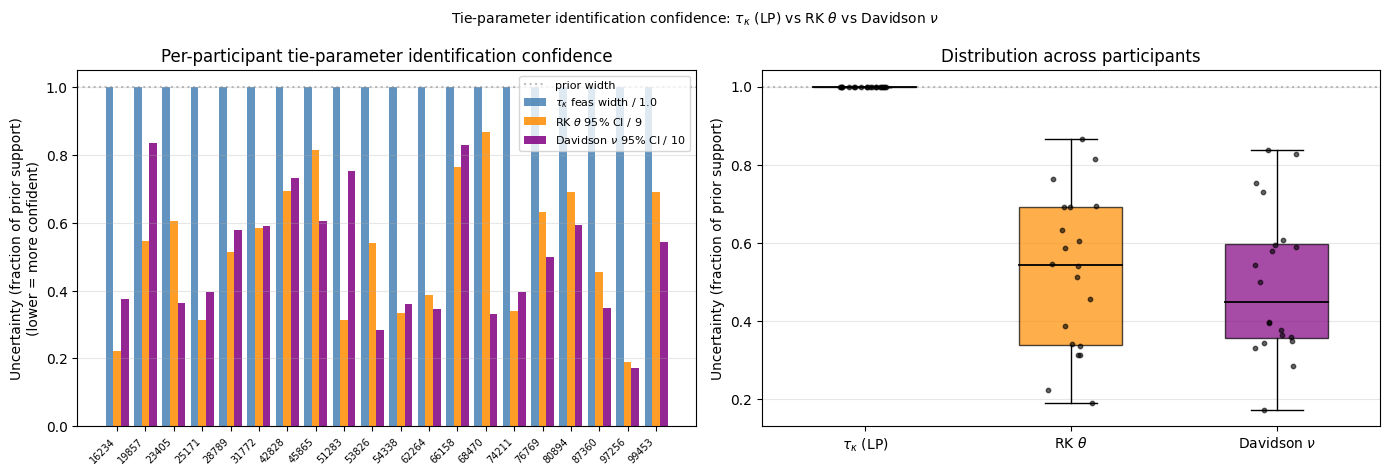


Saved kidney_tie_param_confidence.png


In [23]:
# ─── Tie-parameter identification confidence: τ_κ vs RK θ vs Davidson ν ────
# Compare per-person identification width, all normalised by prior support.

import numpy as np

def _ci95_width(samples):
    lo, hi = np.percentile(samples, [2.5, 97.5])
    return float(hi - lo)

# Participants where all three methods produced a result
persons_cf = sorted(
    [p for p in person_tau.keys()
     if p in rk_results and p in dv_results
     and not np.isnan(person_tau[p]['feas_width'])],
    key=str,
)
n_cf = len(persons_cf)

if n_cf == 0:
    print('No participants are strictly feasible AND have RK + Davidson chains. '
          'Comparison skipped.')
else:
    tau_widths   = np.array([person_tau[p]['feas_width']                  for p in persons_cf])
    theta_widths = np.array([_ci95_width(rk_results[p]['theta_samps'])    for p in persons_cf])
    nu_widths    = np.array([_ci95_width(dv_results[p]['nu_samps'])       for p in persons_cf])

    # Normalise by prior support
    tau_frac   = tau_widths   / 1.0                              # τ_κ ∈ [0, 1]
    theta_frac = theta_widths / (_RK_THETA_MAX - 1.0)           # θ ∈ [1, max]
    nu_frac    = nu_widths    / _DV_NU_MAX                       # ν ∈ [0, max]

    n_conf_arr = np.array([person_tau[p]['n_conf'] for p in persons_cf])

    print(f'Tie-parameter identification confidence ({n_cf} participants)')
    print('═' * 100)
    print(f'{"person":>8}  {"n_conf":>6}  {"τ_κ":>6}  {"τ width":>9}  {"τ frac%":>9}  '
          f'{"θ CI95":>9}  {"θ frac%":>9}  {"ν CI95":>9}  {"ν frac%":>9}')
    print('─' * 100)
    for i, p in enumerate(persons_cf):
        print(f'{p:>8}  {n_conf_arr[i]:>6d}  {person_tau[p]["tau"]:>6.3f}  '
              f'{tau_widths[i]:>9.3f}  {tau_frac[i]*100:>8.1f}%  '
              f'{theta_widths[i]:>9.3f}  {theta_frac[i]*100:>8.1f}%  '
              f'{nu_widths[i]:>9.3f}  {nu_frac[i]*100:>8.1f}%')
    print('─' * 100)
    print(f'{"mean":>8}  {n_conf_arr.mean():>6.1f}  {"":>6}  '
          f'{tau_widths.mean():>9.3f}  {tau_frac.mean()*100:>8.1f}%  '
          f'{theta_widths.mean():>9.3f}  {theta_frac.mean()*100:>8.1f}%  '
          f'{nu_widths.mean():>9.3f}  {nu_frac.mean()*100:>8.1f}%')

    # Head-to-head: which method is more confident on each participant?
    print('\nHead-to-head confidence (smaller fraction = more confident)')
    print('═' * 70)
    n_tau_beats_theta = int((tau_frac < theta_frac).sum())
    n_tau_beats_nu    = int((tau_frac < nu_frac).sum())
    n_tau_beats_both  = int(((tau_frac < theta_frac) & (tau_frac < nu_frac)).sum())
    print(f'  τ_κ more identified than RK θ:        {n_tau_beats_theta} / {n_cf}')
    print(f'  τ_κ more identified than Davidson ν:  {n_tau_beats_nu} / {n_cf}')
    print(f'  τ_κ most identified of the three:     {n_tau_beats_both} / {n_cf}')
    print(f'  mean fraction of prior used: τ_κ={tau_frac.mean():.3f}  θ={theta_frac.mean():.3f}  ν={nu_frac.mean():.3f}')

    # ── Plot ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    # Panel 1: per-person bars
    ax = axes[0]
    x  = np.arange(n_cf)
    bw = 0.27
    ax.bar(x - bw, tau_frac,   width=bw, color='steelblue',  alpha=0.85,
           label=r'$\tau_\kappa$ feas width / 1.0')
    ax.bar(x,      theta_frac, width=bw, color='darkorange', alpha=0.85,
           label=fr'RK $\theta$ 95% CI / {_RK_THETA_MAX-1:g}')
    ax.bar(x + bw, nu_frac,    width=bw, color='purple',     alpha=0.85,
           label=fr'Davidson $\nu$ 95% CI / {_DV_NU_MAX:g}')
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5, label='prior width')
    ax.set_xticks(x); ax.set_xticklabels([str(p) for p in persons_cf],
                                          rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Uncertainty (fraction of prior support)\n(lower = more confident)')
    ax.set_title('Per-participant tie-parameter identification confidence')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(axis='y', alpha=0.3)

    # Panel 2: aggregate distribution comparison (boxplots / strips)
    ax = axes[1]
    data    = [tau_frac, theta_frac, nu_frac]
    labels  = [r'$\tau_\kappa$ (LP)', r'RK $\theta$', r'Davidson $\nu$']
    colors  = ['steelblue', 'darkorange', 'purple']
    bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=1.3))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    # Overlay individual points
    rng = np.random.default_rng(0)
    for j, d in enumerate(data, start=1):
        jitter = rng.uniform(-0.12, 0.12, size=len(d))
        ax.scatter(j + jitter, d, c='k', s=10, alpha=0.6, zorder=3)
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
    ax.set_ylabel('Uncertainty (fraction of prior support)')
    ax.set_title('Distribution across participants')
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Tie-parameter identification confidence: '
                 r'$\tau_\kappa$ (LP) vs RK $\theta$ vs Davidson $\nu$', fontsize=10)
    plt.tight_layout()
    plt.savefig('kidney_tie_param_confidence.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('\nSaved kidney_tie_param_confidence.png')
